# Protrusion length per sickle cell — per-condition biology figure

The paper reports (**Figure 2e**) *"average protrusion length per sickle cell, pooled per condition"* — a **single number per condition**, computed as

> `pool_metric = sum(polymer_length_um across FOVs) / sum(n_sickle across FOVs)`

with a 1000-resample bootstrap CI over FOV resampling. The paper's exact numbers (HbAA 8.1 µm, HbSS 25.3 µm, LNP 22.2–22.7 µm, EP 15.3–19.1 µm) are produced by **Idea O** at the very bottom of this notebook.

Everything above Idea O is either **methodology exploration** (Ideas A–N: fiber decomposition, network topology, shape maps, classifier calibration, blob distributions, drop-reason QC, post-hoc threshold sweeps, dist10 persistence) or an **obsolete per-FOV metric view** (`polymer_um_per_100_sickle_cells`, an earlier per-FOV half-violin figure kept as a record of development). These are not what the paper reports.

## Data sources

- `sickling/rbc_classification/experiment_data/per_fov_dist10.parquet` — per-FOV protrusion length + n_sickle + n_cells, filtered with the biologically-motivated `MAX_DIST_FROM_CELL_PX = 10` (see Idea L for how it was derived).
- `sickling/rbc_classification/experiment_data/per_cell.parquet` — per-cell classifier outputs (used by supplementary ideas C, D, E).
- `sickling/rbc_classification/experiment_data/polymer_blobs_dist10.parquet` — per-connected-component protrusion geometry.

## Outputs

- `notebooks/figures/sickle_polymer_per_condition_pool_dist10.svg/png` — the paper Figure 2e metric (Idea O output).
- `notebooks/figures/sickle_polymer_per_condition_pool_dist10.csv` — the pool stats table.

## Metric-name legacy note

Parquet columns retain the `polymer_*` prefix (`polymer_length_um`, `polymer_um_per_100_sickle_cells`, etc.) because they were generated before the manuscript's terminology settled on **HbS protrusion**. Their values *are* the HbS-protrusion measurements of the paper. The obsolete `polymer_um_per_100_cells` column (all cells in the denominator, not just sickle) is present but not used — the paper metric normalises by sickle cells only.

In [1]:
import sys, os
from pathlib import Path

_BOOTSTRAP = Path(os.path.abspath('')).parent
if str(_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_BOOTSTRAP))

import polymer_detection as _pd
REPO_ROOT = Path(_pd.__file__).resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats as _stats

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42

print('REPO_ROOT =', REPO_ROOT)

REPO_ROOT = E:\utku g leica\sickling


In [2]:
# --- inputs (edit me) ----------------------------------------------------
EXPERIMENT_DATA = REPO_ROOT / 'rbc_classification' / 'experiment_data'
PER_FOV_PARQUET = EXPERIMENT_DATA / 'per_fov.parquet'

# Condition groups for the comparison plot. "Controls" can be either
# treated as one merged group (the user's note: ALHi/ALLo/A-UNT 'treat
# this 3 as one sample') or kept separate. Set ``MERGE_NEGATIVE_CONTROLS``
# to control behavior.
NEGATIVE_CONTROL_CONDITIONS = ['ALHi', 'ALLo', 'A-UNT']
POSITIVE_CONTROL_CONDITIONS = ['S-UNT']
TREATMENT_CONDITIONS        = ['SLN1', 'SLHi', 'SE1', 'SE2']
MERGE_NEGATIVE_CONTROLS     = True

# Per the user: 'controls are ALHi, ALLo, A-UNT (treat this 3 as one
# sample) and S-UNT.' So S-UNT stays separate even when the AL/A-UNT
# group is merged. ``CONDITION_ORDER`` controls the column layout in the
# strip plot.
CONDITION_ORDER = (
    ['neg_control'] if MERGE_NEGATIVE_CONTROLS else list(NEGATIVE_CONTROL_CONDITIONS)
) + POSITIVE_CONTROL_CONDITIONS + TREATMENT_CONDITIONS

FIGURES_DIR = REPO_ROOT / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fov_df = pd.read_parquet(PER_FOV_PARQUET)
print(f'per-FOV records  : {len(fov_df)}')
print(f'conditions       : {sorted(fov_df["condition"].unique())}')
print(f'n_sickle range   : {fov_df["n_sickle"].min()} .. {fov_df["n_sickle"].max()}')
print(f'figures dir      : {FIGURES_DIR}')

per-FOV records  : 3008
conditions       : ['A-UNT', 'ALHi', 'ALLo', 'S-UNT', 'SE1', 'SE2', 'SLHi', 'SLN1']
n_sickle range   : 0 .. 22
figures dir      : E:\utku g leica\sickling\notebooks\figures


In [3]:
# Compute the new metric per FOV.
#
# In addition to the classifier-based n_sickle (the existing control), we
# also precompute two alternative sickle-count denominators inspired by
# rbc-class/notebooks/batch_classify_output_schema.md:
#
#   - n_sickle_soft : mean_p_sickle * n_cells — soft / expected count
#                     from the classifier softmax. Smoother than the hard
#                     count at low prevalence.
#   - n_sickle_conv : per-FOV count of cells with
#                     n_convexity_defects >= CONVEXITY_MIN_DEFECTS.
#                     Classifier-free sickle proxy from per_cell.parquet
#                     (schema doc: "sickle typically 2+, smooth disc 0").
#
# All three live as columns on fov_df so the paper figure (and the
# comparison cell at the bottom) can swap denominators via a single
# config toggle without re-running this cell.
CONVEXITY_MIN_DEFECTS = 2

fov_df = fov_df.copy()

# Group label for plotting.
def _group(cond):
    if MERGE_NEGATIVE_CONTROLS and cond in NEGATIVE_CONTROL_CONDITIONS:
        return 'neg_control'
    return cond
fov_df['group'] = fov_df['condition'].map(_group)

# --- alternative denominators -------------------------------------------
# (1) Soft classifier count = mean_p_sickle * n_cells (expected sickle
#     cells per FOV under the softmax distribution).
fov_df['n_sickle_soft'] = fov_df['mean_p_sickle'].astype(float) * fov_df['n_cells'].astype(float)

# (2) Classifier-free count via convexity defects on per_cell.parquet.
PER_CELL_PARQUET = EXPERIMENT_DATA / 'per_cell.parquet'
_pc = pd.read_parquet(PER_CELL_PARQUET, columns=['stem', 'n_convexity_defects'])
_conv = (
    _pc.assign(_is_sk=lambda d: d['n_convexity_defects'] >= CONVEXITY_MIN_DEFECTS)
       .groupby('stem')['_is_sk'].sum()
)
fov_df['n_sickle_conv'] = fov_df['stem'].map(_conv).fillna(0).astype(int)

# polymer_length_um × 100 / n_sickle (classifier denominator — kept as the
# control metric for QA / pick_threshold / dfbd6672). NaN when n_sickle ==
# 0 so the metric is well-defined.
with np.errstate(divide='ignore', invalid='ignore'):
    fov_df['polymer_um_per_100_sickle_cells'] = (
        fov_df['polymer_length_um'] * 100.0 / fov_df['n_sickle'].replace(0, np.nan)
    )

# Quick before-any-filter view.
n_undefined = fov_df['polymer_um_per_100_sickle_cells'].isna().sum()
n_zero_sickle = (fov_df['n_sickle'] == 0).sum()
print(f'FOVs with n_sickle == 0     : {n_zero_sickle}  (metric undefined)')
print(f'FOVs with finite new metric : {(~fov_df["polymer_um_per_100_sickle_cells"].isna()).sum()}')
print(f'metric range (no threshold) : [{fov_df["polymer_um_per_100_sickle_cells"].min():.2f}, '
      f'{fov_df["polymer_um_per_100_sickle_cells"].max():.2f}]')
print()
print('Alternative sickle-count denominators:')
print(f'  classifier      n_sickle      : range {int(fov_df["n_sickle"].min())} .. '
      f'{int(fov_df["n_sickle"].max())}, sum {int(fov_df["n_sickle"].sum())}')
print(f'  soft_classifier n_sickle_soft : range {fov_df["n_sickle_soft"].min():.2f} .. '
      f'{fov_df["n_sickle_soft"].max():.2f}, sum {fov_df["n_sickle_soft"].sum():.0f}')
print(f'  convexity (>= {CONVEXITY_MIN_DEFECTS}) n_sickle_conv : range '
      f'{int(fov_df["n_sickle_conv"].min())} .. {int(fov_df["n_sickle_conv"].max())}, '
      f'sum {int(fov_df["n_sickle_conv"].sum())}')

FOVs with n_sickle == 0     : 882  (metric undefined)
FOVs with finite new metric : 2126
metric range (no threshold) : [0.00, 24559.64]

Alternative sickle-count denominators:
  classifier      n_sickle      : range 0 .. 22, sum 7696
  soft_classifier n_sickle_soft : range 0.00 .. 22.58, sum 8147
  convexity (>= 2) n_sickle_conv : range 1 .. 253, sum 118724


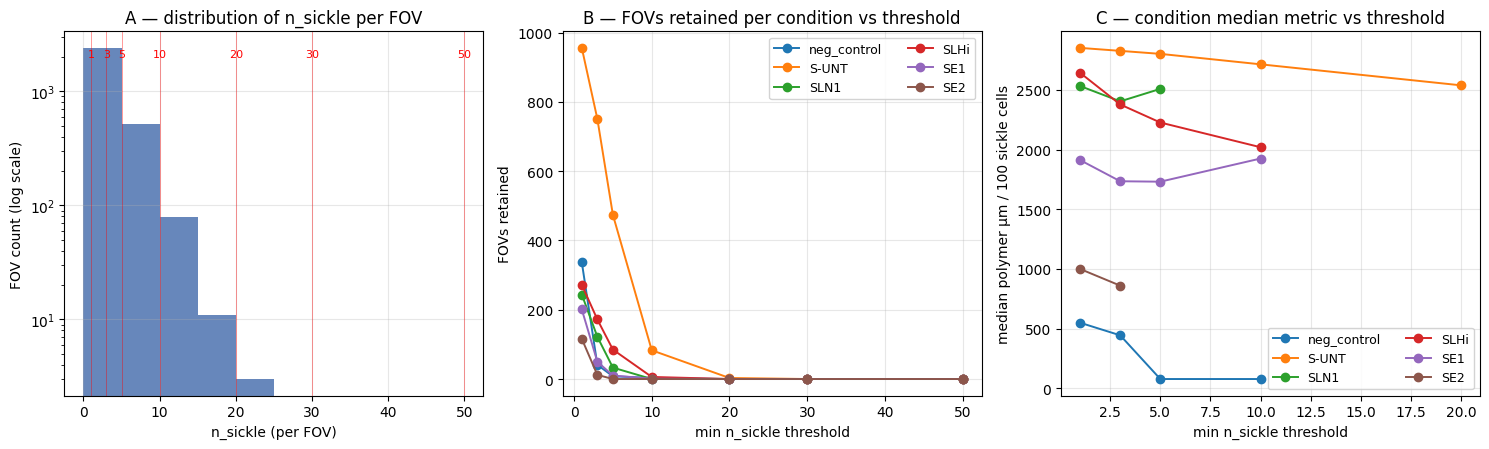

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_threshold_qa.svg
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_threshold_qa.png

          th>=  1  th>=  3  th>=  5  th>= 10  th>= 20  th>= 30  th>= 50
  neg_control    337      41       8       3       0       0       0
  S-UNT          956     751     474      83       3       0       0
  SLN1           244     122      33       0       0       0       0
  SLHi           272     172      85       6       0       0       0
  SE1            201      50      10       1       0       0       0
  SE2            116      12       0       0       0       0       0


In [4]:
# Pick the threshold visually. Read the panel, then set MIN_SICKLE below.
MIN_SICKLE_CANDIDATES = [1, 3, 5, 10, 20, 30, 50]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# A) Histogram of n_sickle per FOV (log y so heavy tail is visible).
ax = axes[0]
bins = np.arange(0, fov_df['n_sickle'].max() + 5, 5)
ax.hist(fov_df['n_sickle'], bins=bins, color='#4c72b0', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('n_sickle (per FOV)')
ax.set_ylabel('FOV count (log scale)')
ax.set_title('A — distribution of n_sickle per FOV')
for t in MIN_SICKLE_CANDIDATES:
    ax.axvline(t, color='red', linewidth=0.7, alpha=0.4)
    ax.text(t, ax.get_ylim()[1] * 0.6, str(t), color='red', ha='center', fontsize=8)
ax.grid(alpha=0.3)

# B) FOVs retained per condition vs candidate threshold.
ax = axes[1]
groups_present = [g for g in CONDITION_ORDER if g in fov_df['group'].unique()]
for g in groups_present:
    sub = fov_df[fov_df['group'] == g]
    n_retained = [(sub['n_sickle'] >= t).sum() for t in MIN_SICKLE_CANDIDATES]
    ax.plot(MIN_SICKLE_CANDIDATES, n_retained, marker='o', label=g, linewidth=1.4)
ax.set_xlabel('min n_sickle threshold')
ax.set_ylabel('FOVs retained')
ax.set_title('B — FOVs retained per condition vs threshold')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.85)
ax.grid(alpha=0.3)

# C) Median metric per condition vs candidate threshold.
ax = axes[2]
for g in groups_present:
    sub = fov_df[fov_df['group'] == g]
    medians = []
    for t in MIN_SICKLE_CANDIDATES:
        kept = sub[sub['n_sickle'] >= t]['polymer_um_per_100_sickle_cells'].dropna()
        medians.append(float(kept.median()) if len(kept) else float('nan'))
    ax.plot(MIN_SICKLE_CANDIDATES, medians, marker='o', label=g, linewidth=1.4)
ax.set_xlabel('min n_sickle threshold')
ax.set_ylabel('median polymer µm / 100 sickle cells')
ax.set_title('C — condition median metric vs threshold')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.85)
ax.grid(alpha=0.3)

fig.tight_layout()
qa_svg = FIGURES_DIR / 'sickle_polymer_threshold_qa.svg'
qa_png = FIGURES_DIR / 'sickle_polymer_threshold_qa.png'
fig.savefig(qa_svg, bbox_inches='tight')
fig.savefig(qa_png, dpi=200, bbox_inches='tight')
plt.show()
print(f'wrote: {qa_svg}')
print(f'wrote: {qa_png}')

# Print a small table so the threshold pick is data-driven, not eyeballed.
print('\n          ' + '  '.join(f'th>={t:>3}' for t in MIN_SICKLE_CANDIDATES))
for g in groups_present:
    sub = fov_df[fov_df['group'] == g]
    n_retained = [(sub['n_sickle'] >= t).sum() for t in MIN_SICKLE_CANDIDATES]
    print(f'  {g:11s} ' + '  '.join(f'{n:>6}' for n in n_retained))

In [5]:
# --- pick the threshold based on panel A/B/C above -----------------------
# MIN_SICKLE filters volatile single-sickle FOVs out of the polymer-per-
# sickle-cell metric. It is intentionally NOT applied to the negative
# control group: neg_control is the no-sickling baseline, so most of its
# FOVs have very few sickle cells by design — filtering them out would
# erase the control. Per-FOV metric values are still NaN-dropped
# downstream wherever n_sickle == 0 (undefined denominator).
MIN_SICKLE = 3
SKIP_MIN_SICKLE_FOR = {'neg_control'}

_pass_min_sickle = (
    (fov_df['n_sickle'] >= MIN_SICKLE)
    | fov_df['group'].isin(SKIP_MIN_SICKLE_FOR)
)
kept_df = fov_df[_pass_min_sickle].copy()
dropped = len(fov_df) - len(kept_df)
print(f'threshold: n_sickle >= {MIN_SICKLE}   '
      f'(skipped for: {sorted(SKIP_MIN_SICKLE_FOR)})')
print(f'  retained: {len(kept_df)}  /  total: {len(fov_df)}  '
      f'(dropped {dropped} = {100 * dropped / len(fov_df):.1f}%)')
print()
print(f'per condition retained:')
for g in CONDITION_ORDER:
    sub = kept_df[kept_df['group'] == g]
    n = len(sub)
    n_finite = int(sub['polymer_um_per_100_sickle_cells'].notna().sum())
    tag = '  (n_sickle filter skipped)' if g in SKIP_MIN_SICKLE_FOR else ''
    if n:
        print(f'  {g:11s}  {n:>5} FOVs  ({n_finite} with finite metric){tag}')

threshold: n_sickle >= 3   (skipped for: ['neg_control'])
  retained: 1971  /  total: 3008  (dropped 1037 = 34.5%)

per condition retained:
  neg_control    864 FOVs  (337 with finite metric)  (n_sickle filter skipped)
  S-UNT          751 FOVs  (751 with finite metric)
  SLN1           122 FOVs  (122 with finite metric)
  SLHi           172 FOVs  (172 with finite metric)
  SE1             50 FOVs  (50 with finite metric)
  SE2             12 FOVs  (12 with finite metric)


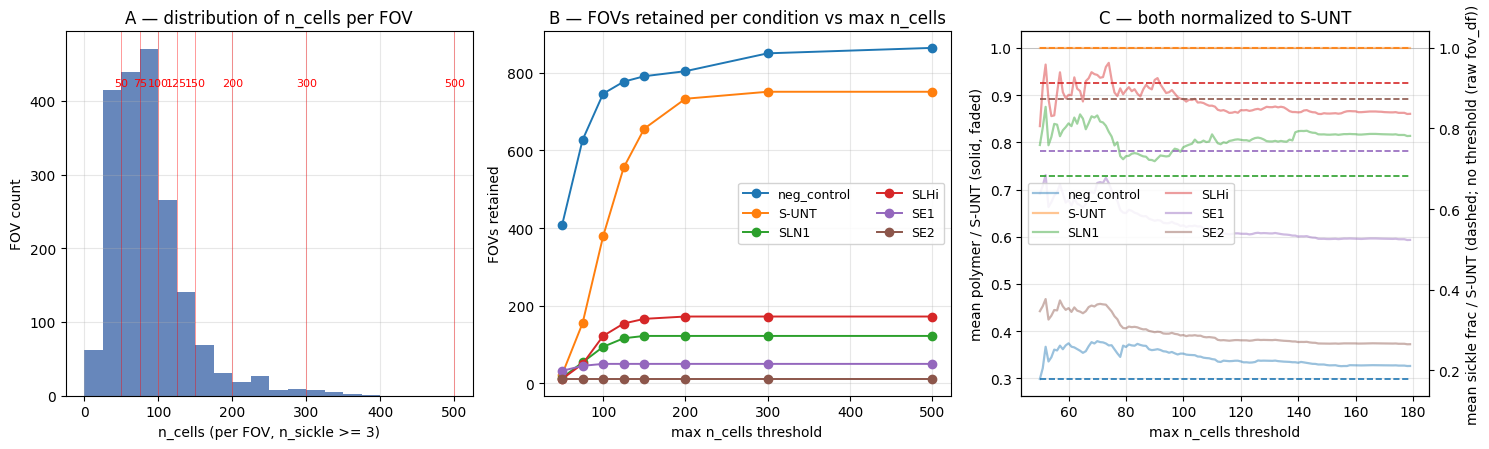

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_max_cells_qa.svg
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_max_cells_qa.png

           <=   50  <=   75  <=  100  <=  125  <=  150  <=  200  <=  300  <=  500
  neg_control    407     627     746     777     791     804     850     864
  S-UNT           22     155     379     556     656     733     751     751
  SLN1            14      54      94     116     122     122     122     122
  SLHi            11      50     122     154     166     172     172     172
  SE1             32      45      50      50      50      50      50      50
  SE2             12      12      12      12      12      12      12      12


In [6]:
# =========================================================================
# QA panel for the UPPER threshold (max n_cells per FOV).
# Mirrors the qa_panel above but for FOV crowding: crowded FOVs likely
# have polymers overlapping unrelated cells -> biased polymer length.
# The QA uses kept_df (already n_sickle >= MIN_SICKLE) since the max-cells
# threshold is applied on top of the sickle threshold.
# =========================================================================
MAX_CELLS_CANDIDATES      = [50, 75, 100, 125, 150, 200, 300, 500]
# Panel C uses a finer grid focused on the low-count regime.
MAX_CELLS_CANDIDATES_FINE = list(range(50, 180))

# Toggle for Panel C: should the dashed sickle-fraction line be computed
# from the threshold-filtered population (True) or the raw fov_df (False)?
# Default False — flat per-group baseline so you can see how restricting
# the population changes the mean sickle fraction when set to True.
APPLY_THRESHOLDS_TO_SICKLE_FRAC = False

# Panel C is normalized to this reference group (positive control). Both
# solid (polymer) and dashed (sickle fraction) lines are divided by the
# reference's value at the same threshold — so the reference reads 1.0
# everywhere and other groups read as "fraction of <ref>". Set to None
# to plot raw values instead.
PANEL_C_REFERENCE = 'S-UNT'

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# A) Histogram of n_cells per FOV (after MIN_SICKLE filter).
ax = axes[0]
n_cells_max = int(kept_df['n_cells'].max())
bins = np.arange(0, n_cells_max + 25, 25)
ax.hist(kept_df['n_cells'], bins=bins, color='#4c72b0', alpha=0.85)
ax.set_xlabel(f'n_cells (per FOV, n_sickle >= {MIN_SICKLE})')
ax.set_ylabel('FOV count')
ax.set_title('A — distribution of n_cells per FOV')
for t in MAX_CELLS_CANDIDATES:
    ax.axvline(t, color='red', linewidth=0.7, alpha=0.4)
    ax.text(t, ax.get_ylim()[1] * 0.85, str(t), color='red', ha='center', fontsize=8)
ax.grid(alpha=0.3)

# B) FOVs retained per condition vs candidate max-cells threshold.
ax = axes[1]
groups_present = [g for g in CONDITION_ORDER if g in kept_df['group'].unique()]
for g in groups_present:
    sub = kept_df[kept_df['group'] == g]
    n_retained = [(sub['n_cells'] <= t).sum() for t in MAX_CELLS_CANDIDATES]
    ax.plot(MAX_CELLS_CANDIDATES, n_retained, marker='o', label=g, linewidth=1.4)
ax.set_xlabel('max n_cells threshold')
ax.set_ylabel('FOVs retained')
ax.set_title('B — FOVs retained per condition vs max n_cells')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.85)
ax.grid(alpha=0.3)

# C) Mean polymer metric (faded solid line, left axis) + mean sickle
#    fraction (dashed line, right axis) per condition vs candidate
#    threshold, BOTH normalized to PANEL_C_REFERENCE at the same
#    threshold. The polymer metric always uses the doubly-filtered
#    sub-population; the dashed line obeys APPLY_THRESHOLDS_TO_SICKLE_FRAC.

def _group_metric_at(t, sub_kept, sub_raw):
    """Return (mean_polymer_metric, sickle_fraction) at candidate t."""
    keep = sub_kept[sub_kept['n_cells'] <= t]
    vals = keep['polymer_um_per_100_sickle_cells'].dropna()
    mean = float(vals.mean()) if len(vals) else float('nan')
    src = keep if APPLY_THRESHOLDS_TO_SICKLE_FRAC else sub_raw
    ns = float(src['n_sickle'].sum())
    nc = float(src['n_cells'].sum())
    sf = ns / nc if nc > 0 else float('nan')
    return mean, sf

# Reference series (recomputed once).
if PANEL_C_REFERENCE is not None:
    _ref_kept = kept_df[kept_df['group'] == PANEL_C_REFERENCE]
    _ref_raw  = fov_df[fov_df['group']  == PANEL_C_REFERENCE]
    ref_means, ref_sfracs = [], []
    for t in MAX_CELLS_CANDIDATES_FINE:
        m, sf = _group_metric_at(t, _ref_kept, _ref_raw)
        ref_means.append(m); ref_sfracs.append(sf)
    ref_means  = np.array(ref_means,  dtype=float)
    ref_sfracs = np.array(ref_sfracs, dtype=float)
else:
    ref_means = ref_sfracs = None

ax = axes[2]
ax_sf = ax.twinx()
for g in groups_present:
    sub_kept = kept_df[kept_df['group'] == g]
    sub_raw  = fov_df[fov_df['group']  == g]
    means, sfracs = [], []
    for t in MAX_CELLS_CANDIDATES_FINE:
        m, sf = _group_metric_at(t, sub_kept, sub_raw)
        means.append(m); sfracs.append(sf)
    y_solid  = np.array(means,  dtype=float)
    y_dashed = np.array(sfracs, dtype=float)
    if PANEL_C_REFERENCE is not None:
        y_solid  = y_solid  / ref_means
        y_dashed = y_dashed / ref_sfracs
    line, = ax.plot(MAX_CELLS_CANDIDATES_FINE, y_solid,
                    linewidth=1.6, alpha=0.45, label=g)
    ax_sf.plot(MAX_CELLS_CANDIDATES_FINE, y_dashed,
               linewidth=1.2, linestyle='--', color=line.get_color())

# Reference line at 1.0 on the left axis for orientation.
if PANEL_C_REFERENCE is not None:
    ax.axhline(1.0, color='gray', linewidth=0.6, alpha=0.5, zorder=1)

ax.set_xlabel('max n_cells threshold')
sf_tag = 'both thresholds applied' if APPLY_THRESHOLDS_TO_SICKLE_FRAC else 'no threshold (raw fov_df)'
if PANEL_C_REFERENCE is None:
    ax.set_ylabel('mean polymer µm / 100 sickle cells (solid, faded)')
    ax_sf.set_ylabel(f'mean sickle fraction (dashed; {sf_tag})')
    ax.set_title('C — mean metric (solid) + mean sickle fraction (dashed)')
else:
    ax.set_ylabel(f'mean polymer / {PANEL_C_REFERENCE} (solid, faded)')
    ax_sf.set_ylabel(f'mean sickle frac / {PANEL_C_REFERENCE} (dashed; {sf_tag})')
    ax.set_title(f'C — both normalized to {PANEL_C_REFERENCE}')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.85)
ax.grid(alpha=0.3)

fig.tight_layout()
qa_svg = FIGURES_DIR / 'sickle_polymer_max_cells_qa.svg'
qa_png = FIGURES_DIR / 'sickle_polymer_max_cells_qa.png'
fig.savefig(qa_svg, bbox_inches='tight')
fig.savefig(qa_png, dpi=200, bbox_inches='tight')
plt.show()
print(f'wrote: {qa_svg}')
print(f'wrote: {qa_png}')

# Compact data-driven table mirroring the n_sickle QA.
print('\n           ' + '  '.join(f'<= {t:>4}' for t in MAX_CELLS_CANDIDATES))
for g in groups_present:
    sub = kept_df[kept_df['group'] == g]
    n_retained = [(sub['n_cells'] <= t).sum() for t in MAX_CELLS_CANDIDATES]
    print(f'  {g:11s} ' + '  '.join(f'{n:>6}' for n in n_retained))

In [7]:
# --- pick the upper threshold based on the QA panel above ----------------
# Upper bound on FOV crowding. In crowded FOVs polymers can overlap
# unrelated cells, biasing per-FOV polymer length upward.
MAX_CELLS = 500

before_n = len(kept_df)
kept_df = kept_df[kept_df['n_cells'] <= MAX_CELLS].copy()
dropped = before_n - len(kept_df)
print(f'threshold: n_cells <= {MAX_CELLS}')
print(f'  retained: {len(kept_df)}  /  pre-filter: {before_n}  '
      f'(dropped {dropped} = {100 * dropped / before_n:.1f}%)')
print()
print(f'per condition retained (after BOTH n_sickle and n_cells thresholds):')
for g in CONDITION_ORDER:
    n = (kept_df['group'] == g).sum()
    if n: print(f'  {g:11s}  {n:>5} FOVs')

threshold: n_cells <= 500
  retained: 1971  /  pre-filter: 1971  (dropped 0 = 0.0%)

per condition retained (after BOTH n_sickle and n_cells thresholds):
  neg_control    864 FOVs
  S-UNT          751 FOVs
  SLN1           122 FOVs
  SLHi           172 FOVs
  SE1             50 FOVs
  SE2             12 FOVs


In [8]:
# =============================================================
# Figure config — edit these to tweak the paper figure quickly.
# =============================================================
PLOT_STYLE        = 'half_violin'   # 'half_violin' or 'scatter'
APPLY_TUKEY       = True            # outlier exclusion on the polymer metric
TUKEY_K           = 1            # 1.5 = classic outlier, 3 = extreme outlier

# Which polymer-length metric drives the violin / scatter on the left
# y-axis. Both columns live in per_fov.parquet:
#   'major_axis' -> polymer_length_um           (sum of regionprops
#                                                major-axis lengths)
#   'skeleton'   -> polymer_skeleton_length_um  (sum of skeletonized
#                                                pixel lengths)
# Each is divided by the chosen sickle-count denominator below.
POLYMER_LENGTH_SOURCE = 'major_axis'   # 'major_axis' or 'skeleton'

# Which sickle-count denominator the per-FOV ratio uses.
#   'classifier'      -> n_sickle           (hard DinoV2 prediction, CONTROL)
#   'soft_classifier' -> n_sickle_soft      (mean_p_sickle * n_cells)
#   'convexity'       -> n_sickle_conv      (cells with n_convexity_defects
#                                            >= CONVEXITY_MIN_DEFECTS;
#                                            classifier-FREE proxy)
# The MIN_SICKLE / MAX_CELLS thresholds still filter on the classifier
# n_sickle, so the same FOV set is included regardless of choice — only
# the per-FOV ratio changes. The comparison cell at the bottom plots all
# three side by side automatically.
SICKLE_COUNT_SOURCE = 'classifier'

# Colors (RGBA hex; the half-violin fill keeps its low alpha)
VIOLIN_FILL       = '#c1440e38'
VIOLIN_BORDER     = '#c1440eff'
MEAN_DOT_COLOR    = '#c1440eff'
SICKLE_FRAC_COLOR = '#1719e7ff'

# Right y-axis (sickle fraction) — fixed range per request.
SICKLE_FRAC_YLIM  = (-0.007, 0.16)
if APPLY_TUKEY:
    SICKLE_FRAC_YLIM  = (-0.007, 0.115)

# Half-violin geometry.
VIOLIN_HALF_WIDTH = 0.35            # max horizontal extent on the right side of x
VIOLIN_SIDE       = 'right'         # 'right' or 'left'

---

> ⚠️  **The half-violin figure below is NOT the paper metric.** It shows the per-FOV distribution of `polymer_length_um / n_sickle` values (one dot per FOV, half-violin over FOVs). The paper reports the **pooled** ratio (one number per condition, computed as `sum(polymer_length_um) / sum(n_sickle)` across all FOVs). Scroll to **Idea O** at the bottom for the paper metric.

This block is retained as a record of the methodology exploration.


plot style: half_violin    Tukey: True (k=1)    num: major_axis (polymer_length_um)    den: classifier (n_sickle)
  group        n_kept  n_excl     mean       q1       q3  sickle_frac
  neg_control     297      40     5.83     1.65     8.71       0.0090
  S-UNT           705      46    28.00    19.81    35.95       0.0503
  SLN1            113       9    22.29    15.11    27.82       0.0343
  SLHi            165       7    24.84    16.92    31.88       0.0460
  SE1              47       3    16.48    10.81    22.89       0.0374
  SE2              12       0    11.26     6.39    17.01       0.0440


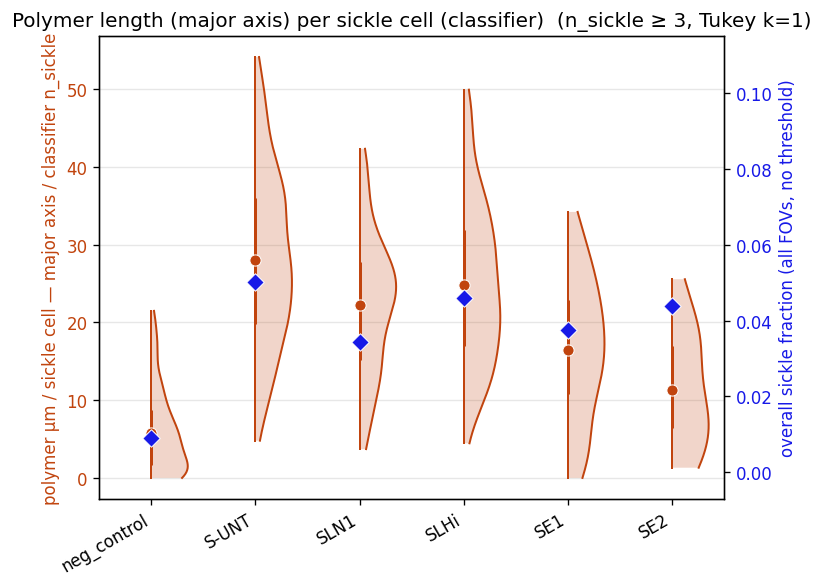

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition.svg
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition.png


In [9]:
# Scatter fallback geometry (used when PLOT_STYLE == 'scatter').
JITTER, MEAN_HW, QUART_HW = 0.10, 0.22, 0.13
# =============================================================

from scipy.stats import gaussian_kde

def _tukey_keep(vals, k):
    """Return values inside [Q1 - k*IQR, Q3 + k*IQR]."""
    if vals.size < 4:
        return vals
    q1, q3 = np.quantile(vals, [0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return vals[(vals >= lo) & (vals <= hi)]

def _draw_half_violin(ax, x_center, vals, *, side, half_width, fill, border):
    if vals.size < 2 or np.allclose(vals, vals[0]):
        return
    kde = gaussian_kde(vals)
    y_grid = np.linspace(vals.min(), vals.max(), 256)
    density = kde(y_grid)
    if density.max() <= 0:
        return
    density = density / density.max() * half_width
    if side == 'right':
        xs = x_center + density
    else:
        xs = x_center - density
    # Fill (low alpha) bounded by the centerline.
    ax.fill_betweenx(y_grid, x_center, xs, facecolor=fill, edgecolor='none', zorder=2)
    # KDE outline + closing centerline.
    ax.plot(xs, y_grid, color=border, linewidth=1.2, zorder=3)
    ax.plot([x_center, x_center], [y_grid[0], y_grid[-1]], color=border, linewidth=1.2, zorder=3)

# ----- assemble the per-group values (left y-axis) ------------------------
# Numerator: polymer length (major axis or skeleton).
# Denominator: chosen sickle-count source.
_LEN_COL = {
    'major_axis': 'polymer_length_um',
    'skeleton':   'polymer_skeleton_length_um',
}[POLYMER_LENGTH_SOURCE]
_SOURCE_LABEL = {
    'major_axis': 'major axis',
    'skeleton':   'skeleton',
}[POLYMER_LENGTH_SOURCE]
_DEN_COL = {
    'classifier':      'n_sickle',
    'soft_classifier': 'n_sickle_soft',
    'convexity':       'n_sickle_conv',
}[SICKLE_COUNT_SOURCE]
_DEN_LABEL = {
    'classifier':      'classifier n_sickle',
    'soft_classifier': 'soft classifier mean_p·n_cells',
    'convexity':       f'convexity ≥{CONVEXITY_MIN_DEFECTS} (clf-free)',
}[SICKLE_COUNT_SOURCE]

groups_present = [g for g in CONDITION_ORDER if g in kept_df['group'].unique()]
raw_by_group = []
for g in groups_present:
    sub = kept_df[(kept_df['group'] == g) & (kept_df[_DEN_COL] > 0)]
    vals = (sub[_LEN_COL] / sub[_DEN_COL]).dropna().to_numpy()
    raw_by_group.append(vals)

if APPLY_TUKEY:
    plot_by_group = [_tukey_keep(v, TUKEY_K) for v in raw_by_group]
else:
    plot_by_group = raw_by_group
n_excluded = [int(r.size - p.size) for r, p in zip(raw_by_group, plot_by_group)]

# ----- sickle fraction per group (right y-axis) ---------------------------
# Aggregated across *all* FOVs in fov_df — MIN_SICKLE threshold does NOT
# apply here (per user spec). One single point per group.
sickle_frac = []
for g in groups_present:
    sub_all = fov_df[fov_df['group'] == g]
    total_sickle = float(sub_all['n_sickle'].sum())
    total_cells  = float(sub_all['n_cells'].sum())
    sickle_frac.append(total_sickle / total_cells if total_cells > 0 else float('nan'))

# ----- draw ---------------------------------------------------------------
rng = np.random.default_rng(0)
fig_w = max(5.0, 1.1 * len(groups_present))
fig, ax = plt.subplots(figsize=(fig_w, 5.0), dpi=120)

for i, (g, vals) in enumerate(zip(groups_present, plot_by_group)):
    x = i + 1
    if vals.size == 0:
        continue
    if PLOT_STYLE == 'half_violin':
        _draw_half_violin(ax, x, vals,
                          side=VIOLIN_SIDE, half_width=VIOLIN_HALF_WIDTH,
                          fill=VIOLIN_FILL, border=VIOLIN_BORDER)
    else:  # 'scatter'
        jitter = rng.uniform(-JITTER, JITTER, size=vals.size)
        ax.scatter(np.full_like(vals, x) + jitter, vals,
                   s=22, color='black', alpha=0.35, edgecolors='none', zorder=2)

    # Mean dot + IQR vertical bar (shared across both plot styles).
    mean_val = float(np.mean(vals))
    q1, q3 = float(np.quantile(vals, 0.25)), float(np.quantile(vals, 0.75))
    ax.plot([x, x], [q1, q3], color=MEAN_DOT_COLOR, linewidth=1.8, zorder=4,
            solid_capstyle='butt')
    ax.scatter([x], [mean_val], color=MEAN_DOT_COLOR, s=45, zorder=5,
               edgecolors='white', linewidths=0.6)

ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_xlim(0.5, len(groups_present) + 0.5)
ax.set_ylabel(f'polymer µm / sickle cell — {_SOURCE_LABEL} / {_DEN_LABEL}',
              color=VIOLIN_BORDER)
ax.tick_params(axis='y', labelcolor=VIOLIN_BORDER)
tukey_tag = f', Tukey k={TUKEY_K:g}' if APPLY_TUKEY else ''
ax.set_title(f'Polymer length ({_SOURCE_LABEL}) per sickle cell ({SICKLE_COUNT_SOURCE})'
             f'  (n_sickle ≥ {MIN_SICKLE}{tukey_tag})')
ax.grid(alpha=0.3, axis='y')

# ----- right y-axis (sickle fraction) -------------------------------------
ax2 = ax.twinx()
xs2 = np.arange(1, len(groups_present) + 1)
ax2.scatter(xs2, sickle_frac, color=SICKLE_FRAC_COLOR,
            s=55, marker='D', zorder=6,
            edgecolors='white', linewidths=0.6,
            label='overall sickle fraction')
ax2.set_ylim(*SICKLE_FRAC_YLIM)
ax2.set_ylabel('overall sickle fraction (all FOVs, no threshold)',
               color=SICKLE_FRAC_COLOR)
ax2.tick_params(axis='y', labelcolor=SICKLE_FRAC_COLOR)

# Compact diagnostic table.
print(f'plot style: {PLOT_STYLE}    Tukey: {APPLY_TUKEY} (k={TUKEY_K:g})    '
      f'num: {POLYMER_LENGTH_SOURCE} ({_LEN_COL})    den: {SICKLE_COUNT_SOURCE} ({_DEN_COL})')
print(f'  {"group":11s} {"n_kept":>7} {"n_excl":>7} {"mean":>8} {"q1":>8} {"q3":>8} '
      f'{"sickle_frac":>12}')
for g, raw, plot, exc, sf in zip(groups_present, raw_by_group, plot_by_group,
                                  n_excluded, sickle_frac):
    if plot.size:
        print(f'  {g:11s} {plot.size:>7d} {exc:>7d} '
              f'{np.mean(plot):>8.2f} {np.quantile(plot,0.25):>8.2f} '
              f'{np.quantile(plot,0.75):>8.2f} {sf:>12.4f}')
    else:
        print(f'  {g:11s} {0:>7d} {exc:>7d}   ----   ----   ----  {sf:>12.4f}')

fig.tight_layout()
pf_svg = FIGURES_DIR / 'sickle_polymer_per_condition.svg'
pf_png = FIGURES_DIR / 'sickle_polymer_per_condition.png'
fig.savefig(pf_svg, bbox_inches='tight')
fig.savefig(pf_png, dpi=200, bbox_inches='tight')
plt.show()
print(f'wrote: {pf_svg}')
print(f'wrote: {pf_png}')

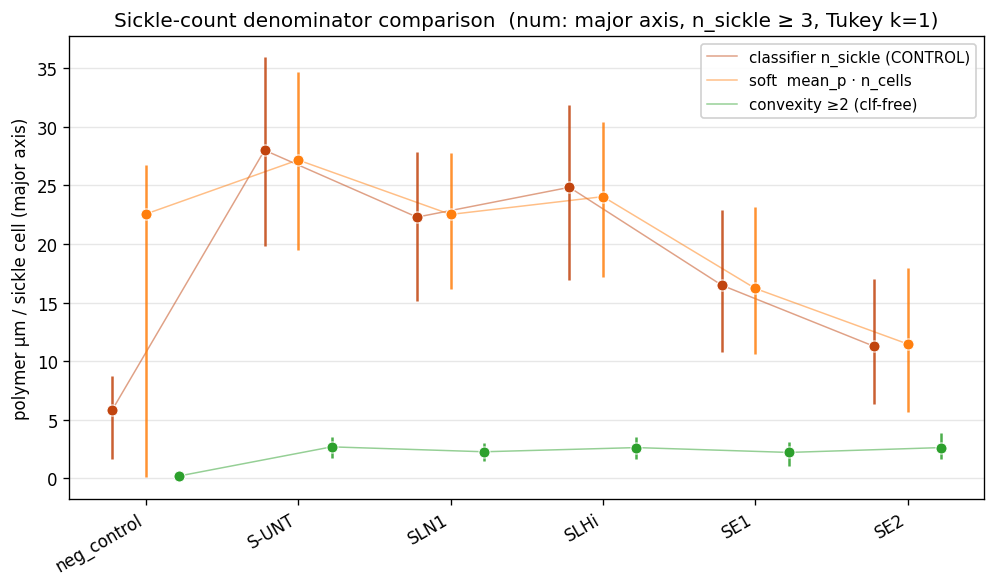

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_method_comparison.svg
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_method_comparison.png

per-group mean polymer µm / sickle cell, by method:
method       classifier  convexity  soft_classifier
group                                              
neg_control        5.83       0.21            22.55
S-UNT             28.00       2.69            27.17
SLN1              22.29       2.27            22.52
SLHi              24.84       2.63            24.04
SE1               16.48       2.22            16.21
SE2               11.26       2.63            11.47

n (finite FOVs) by method:
method       classifier  convexity  soft_classifier
group                                              
neg_control         297        772              697
S-UNT               705        702              717
SLN1                113        118              112
SLHi                165        163              164
SE1              

In [10]:
# =========================================================================
# Sickle-count comparison — runs all three denominators side by side on the
# SAME FOV set (the doubly-filtered kept_df) so the only thing changing
# between methods is *how the per-FOV ratio gets normalised*.
#
# 'classifier' is the experimental control. The other two are candidate
# improvements suggested by batch_classify_output_schema.md:
#   - 'soft_classifier' smooths out the volatility you get when n_sickle
#     is small but mean_p_sickle is non-zero.
#   - 'convexity' is classifier-free; if it agrees with 'classifier' you
#     don't owe the classifier anything, if they disagree it tells you
#     where the classifier is doing real work.
#
# Numerator is the same POLYMER_LENGTH_SOURCE picked above.
# =========================================================================
METHODS = ['classifier', 'soft_classifier', 'convexity']
METHOD_COLORS = {
    'classifier':      '#c1440eff',
    'soft_classifier': '#ff7f0e',
    'convexity':       '#2ca02c',
}
METHOD_OFFSETS = {'classifier': -0.22, 'soft_classifier': 0.0, 'convexity': 0.22}
METHOD_LABELS = {
    'classifier':      'classifier n_sickle (CONTROL)',
    'soft_classifier': 'soft  mean_p · n_cells',
    'convexity':       f'convexity ≥{CONVEXITY_MIN_DEFECTS} (clf-free)',
}
DENOM_COLS = {
    'classifier':      'n_sickle',
    'soft_classifier': 'n_sickle_soft',
    'convexity':       'n_sickle_conv',
}

groups_present = [g for g in CONDITION_ORDER if g in kept_df['group'].unique()]

# Collect (mean, q1, q3, n) for every (group, method).
records = []
for method in METHODS:
    dcol = DENOM_COLS[method]
    for g in groups_present:
        sub = kept_df[(kept_df['group'] == g) & (kept_df[dcol] > 0)]
        vals = (sub[_LEN_COL] / sub[dcol]).dropna().to_numpy()
        if APPLY_TUKEY:
            vals = _tukey_keep(vals, TUKEY_K)
        if vals.size:
            records.append({
                'group': g, 'method': method, 'n': int(vals.size),
                'mean': float(np.mean(vals)),
                'q1':   float(np.quantile(vals, 0.25)),
                'q3':   float(np.quantile(vals, 0.75)),
            })
        else:
            records.append({'group': g, 'method': method, 'n': 0,
                            'mean': float('nan'), 'q1': float('nan'),
                            'q3': float('nan')})
cmp_df = pd.DataFrame(records)

# --- draw: x = condition, three offset markers per condition -------------
fig_w = max(6.0, 1.4 * len(groups_present))
fig, ax = plt.subplots(figsize=(fig_w, 5.0), dpi=120)

for method in METHODS:
    color = METHOD_COLORS[method]
    offset = METHOD_OFFSETS[method]
    means_for_line = []
    xs_for_line    = []
    for i, g in enumerate(groups_present):
        row = cmp_df[(cmp_df['group'] == g) & (cmp_df['method'] == method)].iloc[0]
        if not np.isfinite(row['mean']):
            continue
        x = i + 1 + offset
        ax.plot([x, x], [row['q1'], row['q3']],
                color=color, linewidth=1.5, alpha=0.85, zorder=3,
                solid_capstyle='butt')
        ax.scatter([x], [row['mean']], color=color, s=44, zorder=4,
                   edgecolors='white', linewidths=0.6)
        means_for_line.append(row['mean']); xs_for_line.append(x)
    # Connect this method's means across conditions with a thin line —
    # makes the relative shape per method easy to compare.
    ax.plot(xs_for_line, means_for_line,
            color=color, linewidth=0.9, alpha=0.5, zorder=2,
            label=METHOD_LABELS[method])

ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_xlim(0.5, len(groups_present) + 0.5)
ax.set_ylabel(f'polymer µm / sickle cell ({_SOURCE_LABEL})')
tukey_tag = f', Tukey k={TUKEY_K:g}' if APPLY_TUKEY else ''
ax.set_title(f'Sickle-count denominator comparison  '
             f'(num: {_SOURCE_LABEL}, n_sickle ≥ {MIN_SICKLE}{tukey_tag})')
ax.legend(loc='best', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3, axis='y')

fig.tight_layout()
cmp_svg = FIGURES_DIR / 'sickle_polymer_method_comparison.svg'
cmp_png = FIGURES_DIR / 'sickle_polymer_method_comparison.png'
fig.savefig(cmp_svg, bbox_inches='tight')
fig.savefig(cmp_png, dpi=200, bbox_inches='tight')
plt.show()
print(f'wrote: {cmp_svg}')
print(f'wrote: {cmp_png}')

# --- table: per-group, per-method means + ratio vs the classifier ---------
pivot_mean = cmp_df.pivot(index='group', columns='method', values='mean').reindex(groups_present)
pivot_n    = cmp_df.pivot(index='group', columns='method', values='n').reindex(groups_present)
# Ratio of each method's mean to classifier mean (1.0 means no shift).
ratio = pivot_mean.div(pivot_mean['classifier'], axis=0).round(3)
ratio.columns = [c + '_/clf' for c in ratio.columns]

print()
print('per-group mean polymer µm / sickle cell, by method:')
print(pivot_mean.round(2).to_string())
print()
print('n (finite FOVs) by method:')
print(pivot_n.to_string())
print()
print('ratio vs classifier (1.0 = identical, >1 = method gives larger ratio):')
print(ratio.to_string())

cmp_csv = FIGURES_DIR / 'sickle_polymer_method_comparison.csv'
cmp_df.to_csv(cmp_csv, index=False)
print(f'\nwrote: {cmp_csv}')

In [11]:
# Mann-Whitney U vs the negative-control group for every other condition,
# Benjamini-Hochberg FDR over the comparison set.
CONTROL_GROUP = 'neg_control' if MERGE_NEGATIVE_CONTROLS else NEGATIVE_CONTROL_CONDITIONS[0]
ref_vals = kept_df[kept_df['group'] == CONTROL_GROUP]['polymer_um_per_100_sickle_cells'].dropna().to_numpy()

rows = []
for g in groups_present:
    sub = kept_df[kept_df['group'] == g]
    vals = sub['polymer_um_per_100_sickle_cells'].dropna().to_numpy()
    if len(vals) == 0:
        rows.append({'group': g, 'n_fovs': 0, 'median': float('nan'), 'q1': float('nan'),
                     'q3': float('nan'), 'p_vs_ref': float('nan')})
        continue
    if g == CONTROL_GROUP or len(ref_vals) < 2 or len(vals) < 2:
        p = float('nan')
    else:
        p = float(_stats.mannwhitneyu(vals, ref_vals, alternative='two-sided').pvalue)
    rows.append({
        'group': g,
        'n_fovs': int(len(vals)),
        'median': float(np.median(vals)),
        'q1': float(np.quantile(vals, 0.25)),
        'q3': float(np.quantile(vals, 0.75)),
        'p_vs_ref': p,
    })

stats_df = pd.DataFrame(rows)
# BH-FDR over the non-NaN p-values.
ps = stats_df['p_vs_ref'].to_numpy()
mask = ~np.isnan(ps)
if mask.sum():
    p = ps[mask]
    order = np.argsort(p)
    n = p.size
    adj_sorted = p[order] * n / np.arange(1, n + 1)
    adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
    adj_sorted = np.clip(adj_sorted, 0.0, 1.0)
    adj = np.full(n, np.nan)
    adj[order] = adj_sorted
    bh = np.full_like(ps, np.nan)
    bh[mask] = adj
    stats_df['p_vs_ref_bh'] = bh
else:
    stats_df['p_vs_ref_bh'] = np.nan

print(f'\nMann-Whitney U vs {CONTROL_GROUP} (BH-corrected):')
print(stats_df.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

fov_csv = FIGURES_DIR / 'sickle_polymer_per_fov.csv'
stats_csv = FIGURES_DIR / 'sickle_polymer_per_condition.csv'
out_cols = ['condition', 'group', 'stem', 'n_sickle', 'n_cells',
            'polymer_length_um', 'polymer_um_per_100_cells', 'polymer_um_per_100_sickle_cells']
kept_df[out_cols].to_csv(fov_csv, index=False)
stats_df.to_csv(stats_csv, index=False)
print(f'\nwrote: {fov_csv}')
print(f'wrote: {stats_csv}')


Mann-Whitney U vs neg_control (BH-corrected):
      group  n_fovs  median    q1   q3  p_vs_ref  p_vs_ref_bh
neg_control     337   549.5 180.9 1192       NaN          NaN
      S-UNT     751    2827  2052 3758 3.513e-99    1.757e-98
       SLN1     122    2404  1541 2909 3.682e-32    6.137e-32
       SLHi     172    2378  1708 3373 1.731e-44    4.329e-44
        SE1      50    1735  1105 2472 5.001e-09    6.252e-09
        SE2      12   860.2 639.2 1701    0.1218       0.1218

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_fov.csv
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition.csv


---

## Supplementary analyses — exploring ideas from `batch_classify_output_schema.md`

Each cell below picks one suggestion from the schema doc and plots it
alongside an **appropriate control** so the contribution of the new idea
is visible at a glance:

| cell | idea | source | control |
|---|---|---|---|
| A | fiber decomposition (count vs mean length) | per_fov | total protrusion µm |
| B | branch/endpoint topology ratio | per_fov | total protrusion µm |
| C | 2-D shape map (eccentricity × solidity) | per_cell | 1-D marginal histograms |
| D | p_sickle ↔ convexity calibration | per_cell | overall population mean |
| E | severity stratification (sickle-cell quartiles) | per_cell | pooled mean per group |
| F | per-blob fiber length + aspect ratio | polymer_blobs | per-FOV aggregate |
| G | drop-reason mix + orphan rate (QC) | polymer_blobs | "kept" fraction |

All figures go to `notebooks/figures/idea_*.{svg,png}`.

In [12]:
# Load per_cell.parquet and polymer_blobs.parquet with the full schema.
# (compute_metric loaded a 2-col slice already; the idea cells need the
# full set of morphology / blob columns.) Done once so the idea cells
# stay tight.
PER_CELL_FULL_PARQUET = EXPERIMENT_DATA / 'per_cell.parquet'
POLYMER_BLOBS_PARQUET = EXPERIMENT_DATA / 'polymer_blobs.parquet'

per_cell = pd.read_parquet(PER_CELL_FULL_PARQUET)
per_cell['group'] = per_cell['condition'].map(_group)

blobs = pd.read_parquet(POLYMER_BLOBS_PARQUET)
blobs['group'] = blobs['condition'].map(_group)

print(f'per_cell : {len(per_cell):>7} cells  ({len(per_cell.columns)} cols)')
print(f'blobs    : {len(blobs):>7} blobs  ({len(blobs.columns)} cols)')
print(f'  predicted_label distribution :',
      per_cell['predicted_label'].value_counts().to_dict())
print(f'  blob kept fraction (overall) : {blobs["kept"].mean():.3f}')

per_cell :  215363 cells  (16 cols)
blobs    :  101679 blobs  (14 cols)


  predicted_label distribution : {'non_sickle': 207667, 'sickle': 7696}
  blob kept fraction (overall) : 0.358


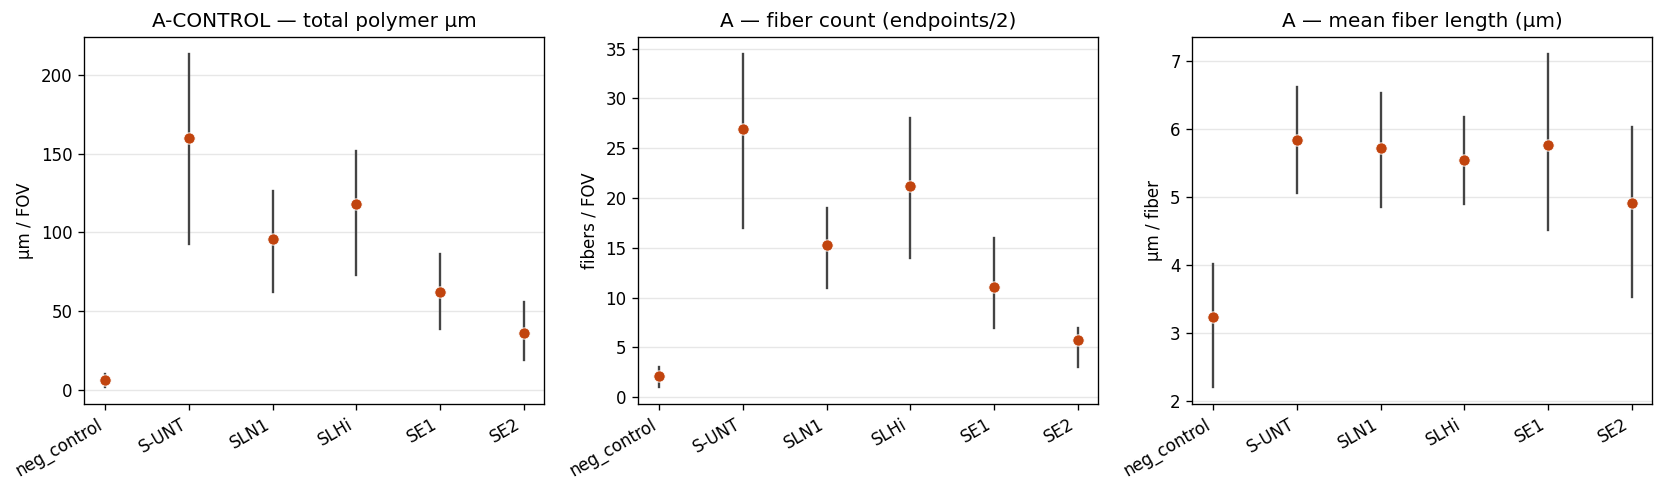

  group         total_µm  fiber_count  mean_fiber_µm
  neg_control      10.77         2.61           3.78
  S-UNT           176.80        29.05           5.96
  SLN1            101.00        16.80           6.03
  SLHi            130.29        22.78           5.73
  SE1              68.76        11.52           5.69
  SE2              35.91         6.46           5.29


In [13]:
# === Idea A: fiber decomposition (total = count × mean_length) ==========
# Schema doc: polymer_endpoints / 2 ≈ fiber count;
# polymer_length_um / fiber_count ≈ mean fiber length per FOV.
#
# Control = total polymer_length_um per FOV (left panel — the standard
# burden metric). The middle and right panels decompose that signal into
# "how many fibers per FOV" × "how long each one is" so you can tell
# whether treatment reduces FIBER COUNT (e.g. nucleation suppression) or
# FIBER LENGTH (e.g. elongation suppression).

sub = kept_df.copy()
sub['fiber_count'] = sub['polymer_endpoints'].astype(float) / 2.0
with np.errstate(divide='ignore', invalid='ignore'):
    sub['mean_fiber_length_um'] = (sub['polymer_length_um']
                                   / sub['fiber_count'].replace(0, np.nan))

groups_present = [g for g in CONDITION_ORDER if g in sub['group'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), dpi=120)
for ax, col, title, ylabel in zip(
    axes,
    ['polymer_length_um', 'fiber_count', 'mean_fiber_length_um'],
    ['A-CONTROL — total polymer µm', 'A — fiber count (endpoints/2)',
     'A — mean fiber length (µm)'],
    ['µm / FOV', 'fibers / FOV', 'µm / fiber'],
):
    for i, g in enumerate(groups_present):
        vals = sub[sub['group'] == g][col].dropna().to_numpy()
        if APPLY_TUKEY: vals = _tukey_keep(vals, TUKEY_K)
        if not vals.size: continue
        x = i + 1
        q1, q3 = np.quantile(vals, [0.25, 0.75])
        ax.plot([x, x], [q1, q3], color='#444', linewidth=1.4)
        ax.scatter([x], [vals.mean()], color='#c1440eff', s=46, zorder=5,
                   edgecolors='white', linewidths=0.5)
    ax.set_xticks(range(1, len(groups_present) + 1))
    ax.set_xticklabels(groups_present, rotation=30, ha='right')
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_A_fiber_decomposition.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_A_fiber_decomposition.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'  {"group":11s} {"total_µm":>10s} {"fiber_count":>12s} {"mean_fiber_µm":>14s}')
for g in groups_present:
    s = sub[sub['group'] == g]
    print(f'  {g:11s} {s["polymer_length_um"].mean():>10.2f} '
          f'{s["fiber_count"].mean():>12.2f} '
          f'{s["mean_fiber_length_um"].mean():>14.2f}')

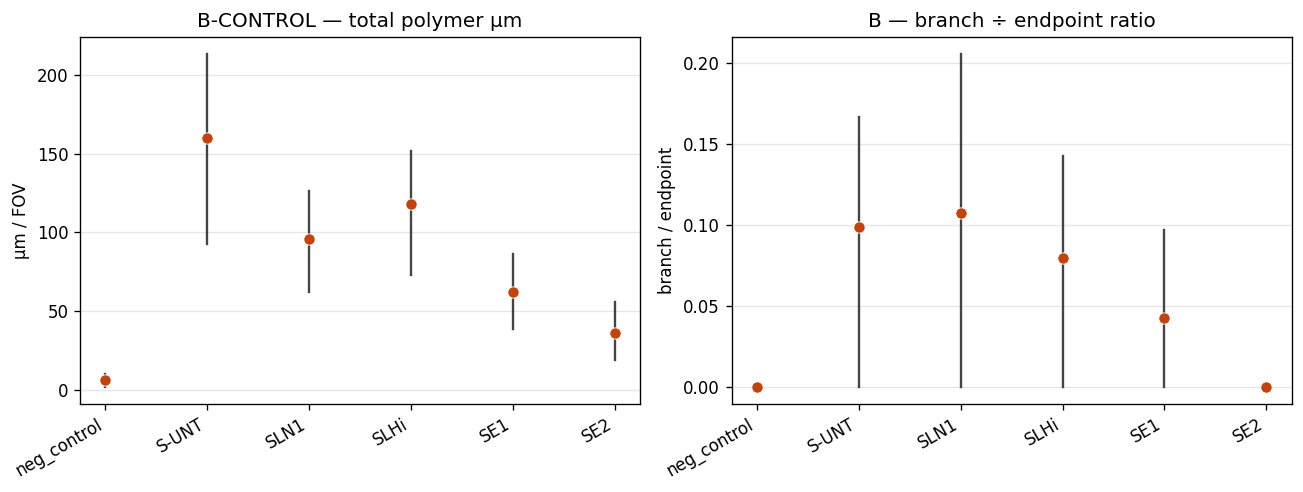

  group         mean_length_um  mean_branch_ratio
  neg_control            10.77              0.027
  S-UNT                 176.80              0.117
  SLN1                  101.00              0.137
  SLHi                  130.29              0.104
  SE1                    68.76              0.103
  SE2                    35.91              0.072


In [14]:
# === Idea B: network topology — branch / endpoint ratio =================
# Schema doc: "branch_points ÷ endpoints captures network complexity;
# branching = more advanced polymerization."
#
# Control = per-FOV total polymer length (the burden signal). If a group
# matches the control on length but differs on branch ratio, the
# topology of polymerization changed without the bulk amount changing —
# a signal the length metric alone would miss.

sub = kept_df.copy()
with np.errstate(divide='ignore', invalid='ignore'):
    sub['branch_ratio'] = (sub['polymer_branch_points'].astype(float)
                           / sub['polymer_endpoints'].replace(0, np.nan))

groups_present = [g for g in CONDITION_ORDER if g in sub['group'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=120)
for ax, col, title, ylabel in zip(
    axes,
    ['polymer_length_um', 'branch_ratio'],
    ['B-CONTROL — total polymer µm', 'B — branch ÷ endpoint ratio'],
    ['µm / FOV', 'branch / endpoint'],
):
    for i, g in enumerate(groups_present):
        vals = sub[sub['group'] == g][col].dropna().to_numpy()
        if APPLY_TUKEY: vals = _tukey_keep(vals, TUKEY_K)
        if not vals.size: continue
        x = i + 1
        q1, q3 = np.quantile(vals, [0.25, 0.75])
        ax.plot([x, x], [q1, q3], color='#444', linewidth=1.4)
        ax.scatter([x], [vals.mean()], color='#c1440eff', s=46, zorder=5,
                   edgecolors='white', linewidths=0.5)
    ax.set_xticks(range(1, len(groups_present) + 1))
    ax.set_xticklabels(groups_present, rotation=30, ha='right')
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_B_branch_ratio.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_B_branch_ratio.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'  {"group":11s} {"mean_length_um":>16s} {"mean_branch_ratio":>18s}')
for g in groups_present:
    s = sub[sub['group'] == g]
    print(f'  {g:11s} {s["polymer_length_um"].mean():>16.2f} '
          f'{s["branch_ratio"].mean():>18.3f}')

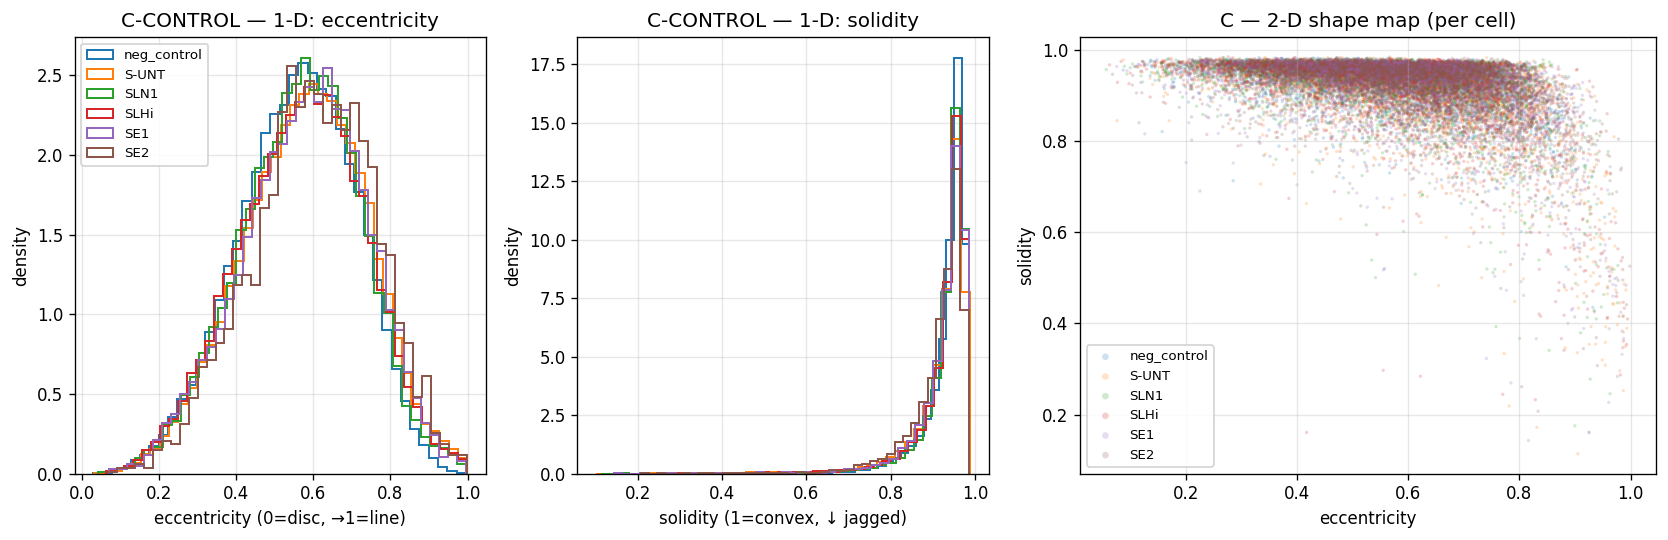

per-group centroid in (eccentricity, solidity):
             eccentricity  solidity
group                              
S-UNT               0.579     0.916
SE1                 0.579     0.922
SE2                 0.600     0.913
SLHi                0.569     0.923
SLN1                0.568     0.927
neg_control         0.558     0.934


In [15]:
# === Idea C: 2-D shape morphology map (eccentricity × solidity) ==========
# Schema doc: "natural sickle / discocyte / echinocyte separation".
#
# Control = the two 1-D marginal histograms (eccentricity alone, solidity
# alone). The 2-D scatter on the right shows whether the JOINT
# distribution separates groups better than either axis alone. If a group
# stacks in one region of (ecc, sol) space that the 1-D histograms don't
# isolate, the 2-D view is the real signal.
#
# Subsample each group to PER_GROUP_MAX cells so the scatter stays
# readable.
PER_GROUP_MAX = 4000
RNG_C = np.random.default_rng(0)

groups_present = [g for g in CONDITION_ORDER if g in per_cell['group'].unique()]
cmap = plt.get_cmap('tab10')
group_colors = {g: cmap(i % 10) for i, g in enumerate(groups_present)}

fig = plt.figure(figsize=(14, 4.6), dpi=120)
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 1.4])

# Marginal histograms (CONTROL).
ax_ecc = fig.add_subplot(gs[0])
ax_sol = fig.add_subplot(gs[1])
for g in groups_present:
    sub = per_cell[per_cell['group'] == g]
    ax_ecc.hist(sub['eccentricity'], bins=40, density=True, histtype='step',
                color=group_colors[g], linewidth=1.2, label=g)
    ax_sol.hist(sub['solidity'], bins=40, density=True, histtype='step',
                color=group_colors[g], linewidth=1.2, label=g)
ax_ecc.set_xlabel('eccentricity (0=disc, →1=line)'); ax_ecc.set_ylabel('density')
ax_ecc.set_title('C-CONTROL — 1-D: eccentricity'); ax_ecc.grid(alpha=0.3)
ax_ecc.legend(loc='upper left', fontsize=8, framealpha=0.85)
ax_sol.set_xlabel('solidity (1=convex, ↓ jagged)'); ax_sol.set_ylabel('density')
ax_sol.set_title('C-CONTROL — 1-D: solidity');     ax_sol.grid(alpha=0.3)

# 2-D scatter — the actual idea.
ax2d = fig.add_subplot(gs[2])
for g in groups_present:
    sub = per_cell[per_cell['group'] == g]
    if len(sub) > PER_GROUP_MAX:
        sub = sub.sample(n=PER_GROUP_MAX, random_state=0)
    ax2d.scatter(sub['eccentricity'], sub['solidity'],
                 s=4, alpha=0.22, color=group_colors[g], edgecolors='none', label=g)
ax2d.set_xlabel('eccentricity'); ax2d.set_ylabel('solidity')
ax2d.set_title('C — 2-D shape map (per cell)')
ax2d.legend(loc='lower left', fontsize=8, framealpha=0.85, markerscale=2)
ax2d.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_C_shape_map.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_C_shape_map.png', dpi=200, bbox_inches='tight')
plt.show()

# Per-group centroid in (ecc, sol) space.
centroid = per_cell.groupby('group')[['eccentricity', 'solidity']].mean().round(3)
print('per-group centroid in (eccentricity, solidity):')
print(centroid.to_string())

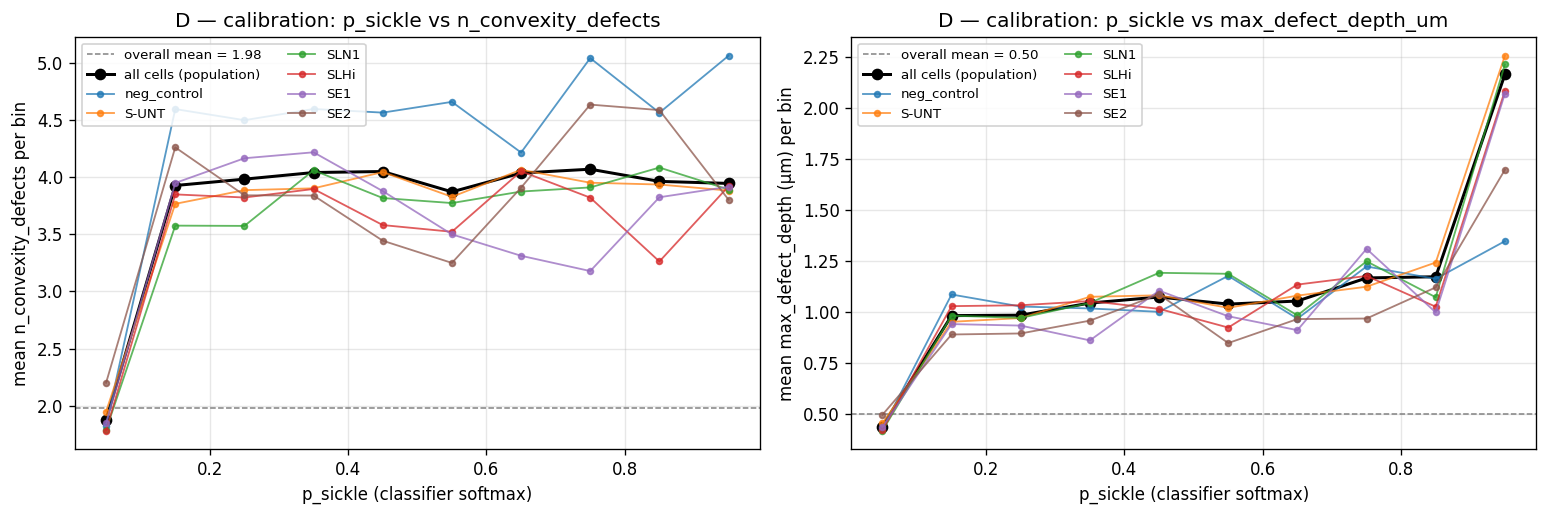

population calibration (all cells):
p_sickle_bin      n  mean_defects  mean_depth_um
     0.0-0.1 204602          1.88           0.44
     0.1-0.2   1260          3.93           0.98
     0.2-0.3    728          3.98           0.98
     0.3-0.4    601          4.04           1.04
     0.4-0.5    476          4.05           1.07
     0.5-0.6    376          3.87           1.04
     0.6-0.7    404          4.04           1.05
     0.7-0.8    439          4.07           1.17
     0.8-0.9    638          3.96           1.17
     0.9-1.0   5839          3.95           2.16


In [16]:
# === Idea D: p_sickle ↔ convexity calibration ============================
# Schema doc: bin cells by p_sickle, plot mean n_convexity_defects per
# bin. Monotonic rise validates BOTH signals.
#
# Control = horizontal line at the overall mean across all cells. A
# population-level curve that sits below the baseline at low p_sickle and
# above it at high p_sickle = the two metrics agree on which cells are
# sickle. A flat curve = the classifier and the shape-based proxy are
# seeing different things.

BINS  = np.linspace(0.0, 1.0, 11)
MIDS  = 0.5 * (BINS[:-1] + BINS[1:])
per_cell['_p_bin'] = pd.cut(per_cell['p_sickle'], BINS, include_lowest=True)
groups_present    = [g for g in CONDITION_ORDER if g in per_cell['group'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), dpi=120)
cmap = plt.get_cmap('tab10')

for ax, ycol, ylabel in zip(
    axes,
    ['n_convexity_defects', 'max_defect_depth_um'],
    ['mean n_convexity_defects per bin',
     'mean max_defect_depth (µm) per bin'],
):
    pop_baseline = float(per_cell[ycol].mean())
    pop_curve = (per_cell.groupby('_p_bin', observed=True)[ycol]
                 .mean().reindex(per_cell['_p_bin'].cat.categories))
    # Control reference: overall mean across all cells, ignoring p_sickle.
    ax.axhline(pop_baseline, color='gray', linestyle='--', linewidth=0.9,
               label=f'overall mean = {pop_baseline:.2f}')
    # Population calibration curve (black, thick).
    ax.plot(MIDS, pop_curve.values, color='black', linewidth=1.8,
            marker='o', label='all cells (population)')
    # Per-group calibration curves.
    for i, g in enumerate(groups_present):
        sub = per_cell[per_cell['group'] == g]
        gc = (sub.groupby('_p_bin', observed=True)[ycol]
              .mean().reindex(per_cell['_p_bin'].cat.categories))
        ax.plot(MIDS, gc.values, color=cmap(i % 10), linewidth=1.1,
                alpha=0.75, marker='.', markersize=7, label=g)
    ax.set_xlabel('p_sickle (classifier softmax)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'D — calibration: p_sickle vs {ycol}')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.85, ncol=2)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_D_calibration.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_D_calibration.png', dpi=200, bbox_inches='tight')
plt.show()

# Print the population calibration as a table.
print('population calibration (all cells):')
calib = pd.DataFrame({
    'p_sickle_bin': [f'{lo:.1f}-{hi:.1f}' for lo, hi in zip(BINS[:-1], BINS[1:])],
    'n':            per_cell.groupby('_p_bin', observed=True).size().reindex(per_cell['_p_bin'].cat.categories).values,
    'mean_defects': per_cell.groupby('_p_bin', observed=True)['n_convexity_defects'].mean().reindex(per_cell['_p_bin'].cat.categories).round(2).values,
    'mean_depth_um': per_cell.groupby('_p_bin', observed=True)['max_defect_depth_um'].mean().reindex(per_cell['_p_bin'].cat.categories).round(2).values,
})
print(calib.to_string(index=False))

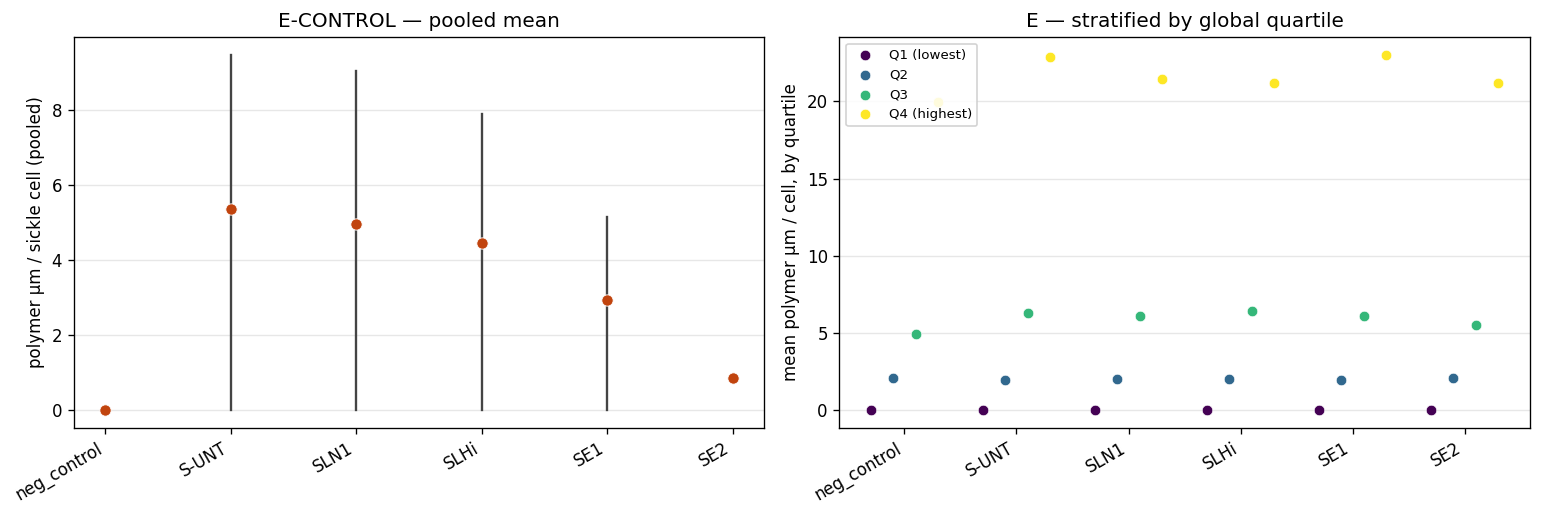

global quartile breakpoints (µm): Q1≤0.00, Q2≤2.43, Q3≤10.75

                          count   mean
group       _quartile                 
S-UNT       Q1 (lowest)    2030   0.00
            Q2              153   1.98
            Q3             1289   6.30
            Q4 (highest)   1373  22.89
SE1         Q1 (lowest)     210   0.00
            Q2               25   1.92
            Q3               86   6.10
            Q4 (highest)     88  23.01
SE2         Q1 (lowest)     108   0.00
            Q2                7   2.06
            Q3               20   5.55
            Q4 (highest)     29  21.15
SLHi        Q1 (lowest)     464   0.00
            Q2               30   1.99
            Q3              299   6.45
            Q4 (highest)    244  21.18
SLN1        Q1 (lowest)     291   0.00
            Q2               15   2.00
            Q3              198   6.11
            Q4 (highest)    183  21.46
neg_control Q1 (lowest)     502   0.00
            Q2               13   2.07
  

In [17]:
# === Idea E: severity stratification by per-cell polymer load ===========
# Schema doc: "among predicted-sickle cells, split by
# assigned_polymer_length_um quartile and compare conditions."
#
# Control = pooled mean per-cell polymer load across all predicted-sickle
# cells in each group (the standard view). Stratification reveals whether
# a condition shifts the WHOLE distribution down (treatment touches every
# sickle cell) or only the top quartile (treatment only clips the worst
# cells while leaving moderate ones untouched). Quartile breakpoints are
# computed ACROSS THE WHOLE PREDICTED-SICKLE POPULATION so they share a
# definition across groups.

sk = per_cell[per_cell['predicted_label'] == 'sickle'].copy()
QUARTILES = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
_q = np.quantile(sk['assigned_polymer_length_um'], [0.25, 0.5, 0.75])
def _label_q(v):
    if v <= _q[0]: return 'Q1 (lowest)'
    if v <= _q[1]: return 'Q2'
    if v <= _q[2]: return 'Q3'
    return 'Q4 (highest)'
sk['_quartile'] = sk['assigned_polymer_length_um'].apply(_label_q)

groups_present = [g for g in CONDITION_ORDER if g in sk['group'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), dpi=120)

# Control: pooled mean per group.
ax = axes[0]
for i, g in enumerate(groups_present):
    vals = sk[sk['group'] == g]['assigned_polymer_length_um'].to_numpy()
    if APPLY_TUKEY: vals = _tukey_keep(vals, TUKEY_K)
    if not vals.size: continue
    x = i + 1
    q1, q3 = np.quantile(vals, [0.25, 0.75])
    ax.plot([x, x], [q1, q3], color='#444', linewidth=1.4)
    ax.scatter([x], [vals.mean()], color='#c1440eff', s=46, zorder=5, edgecolors='white', linewidths=0.5)
ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_ylabel('polymer µm / sickle cell (pooled)')
ax.set_title('E-CONTROL — pooled mean')
ax.grid(alpha=0.3, axis='y')

# Stratified panel.
ax = axes[1]
cmap = plt.get_cmap('viridis')
quart_color = {q: cmap(i / 3.0) for i, q in enumerate(QUARTILES)}
quart_offset = {q: o for q, o in zip(QUARTILES, [-0.3, -0.1, 0.1, 0.3])}
for q in QUARTILES:
    plotted = False
    for i, g in enumerate(groups_present):
        sub = sk[(sk['group'] == g) & (sk['_quartile'] == q)]
        if not len(sub): continue
        x = i + 1 + quart_offset[q]
        ax.scatter([x], [sub['assigned_polymer_length_um'].mean()],
                   color=quart_color[q], s=40, edgecolors='white', linewidths=0.4,
                   label=q if not plotted else None, zorder=4)
        plotted = True
ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_ylabel('mean polymer µm / cell, by quartile')
ax.set_title('E — stratified by global quartile')
ax.legend(loc='upper left', fontsize=8, framealpha=0.85)
ax.grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_E_severity_stratification.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_E_severity_stratification.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'global quartile breakpoints (µm): Q1≤{_q[0]:.2f}, Q2≤{_q[1]:.2f}, Q3≤{_q[2]:.2f}')
print()
strat = sk.groupby(['group', '_quartile'])['assigned_polymer_length_um'].agg(['count','mean']).round(2)
print(strat.to_string())

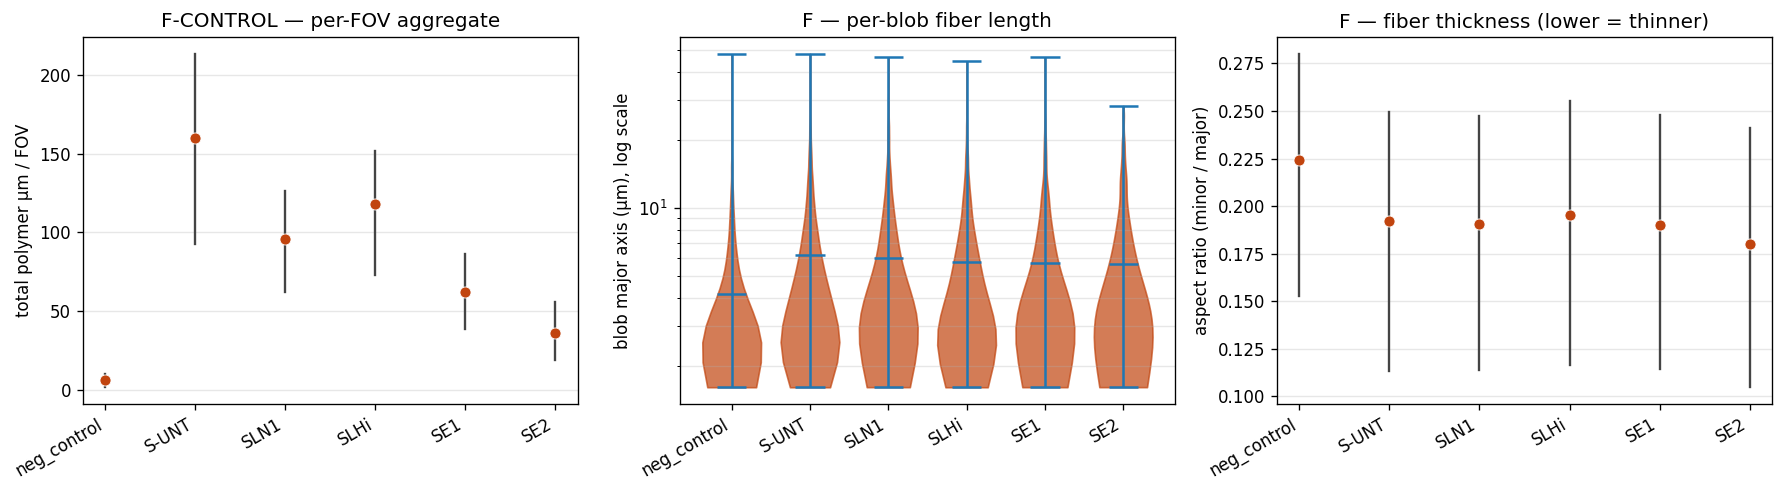

per-condition kept-blob summary:
             n_blobs  median_major_um  mean_major_um  median_aspect
group                                                              
S-UNT          23687             4.28           6.22           0.18
SE1             1815             3.78           5.73           0.18
SE2              620             3.74           5.67           0.17
SLHi            4865             4.09           5.77           0.18
SLN1            3173             4.04           6.01           0.18
neg_control     2229             2.69           4.17           0.22


In [18]:
# === Idea F: per-blob fiber-length distribution + aspect ratio ==========
# Schema doc: violin of blob major axes per condition (log-y because
# lengths span 2+ decades); aspect ratio minor/major distinguishes thin
# filaments (low) from chunky polymer (high).
#
# Control = per-FOV total polymer length (the aggregate we plot in the
# paper figure). If two conditions match on TOTAL length but differ on
# the per-blob length distribution, treatment changed *blob morphology*
# without changing total burden — a biological distinction the aggregate
# would hide.

kept_blobs = blobs[blobs['kept']].copy()
kept_blobs['aspect'] = kept_blobs['minor_um'] / kept_blobs['major_um'].replace(0, np.nan)
groups_present = [g for g in CONDITION_ORDER if g in kept_blobs['group'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=120)

# Control: per-FOV total length (the existing aggregate).
ax = axes[0]
for i, g in enumerate(groups_present):
    vals = kept_df[kept_df['group'] == g]['polymer_length_um'].dropna().to_numpy()
    if APPLY_TUKEY: vals = _tukey_keep(vals, TUKEY_K)
    if not vals.size: continue
    x = i + 1
    q1, q3 = np.quantile(vals, [0.25, 0.75])
    ax.plot([x, x], [q1, q3], color='#444', linewidth=1.4)
    ax.scatter([x], [vals.mean()], color='#c1440eff', s=44, zorder=5, edgecolors='white', linewidths=0.5)
ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_ylabel('total polymer µm / FOV')
ax.set_title('F-CONTROL — per-FOV aggregate')
ax.grid(alpha=0.3, axis='y')

# Per-blob major-axis violin, log y.
ax = axes[1]
data = [kept_blobs[kept_blobs['group'] == g]['major_um'].to_numpy() for g in groups_present]
parts = ax.violinplot(data, positions=range(1, len(groups_present) + 1),
                      showmeans=True, showmedians=False, widths=0.75)
for body in parts['bodies']:
    body.set_facecolor('#c1440e38'); body.set_edgecolor('#c1440eff'); body.set_alpha(0.7)
ax.set_yscale('log')
ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_ylabel('blob major axis (µm), log scale')
ax.set_title('F — per-blob fiber length')
ax.grid(alpha=0.3, axis='y', which='both')

# Aspect ratio (thinness).
ax = axes[2]
for i, g in enumerate(groups_present):
    vals = kept_blobs[kept_blobs['group'] == g]['aspect'].dropna().to_numpy()
    if not vals.size: continue
    x = i + 1
    q1, q3 = np.quantile(vals, [0.25, 0.75])
    ax.plot([x, x], [q1, q3], color='#444', linewidth=1.4)
    ax.scatter([x], [vals.mean()], color='#c1440eff', s=44, zorder=5, edgecolors='white', linewidths=0.5)
ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_ylabel('aspect ratio (minor / major)')
ax.set_title('F — fiber thickness (lower = thinner)')
ax.grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_F_blob_distribution.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_F_blob_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print('per-condition kept-blob summary:')
print(kept_blobs.groupby('group').agg(
    n_blobs=('blob_id', 'size'),
    median_major_um=('major_um', 'median'),
    mean_major_um=('major_um', 'mean'),
    median_aspect=('aspect', 'median'),
).round(2).to_string())

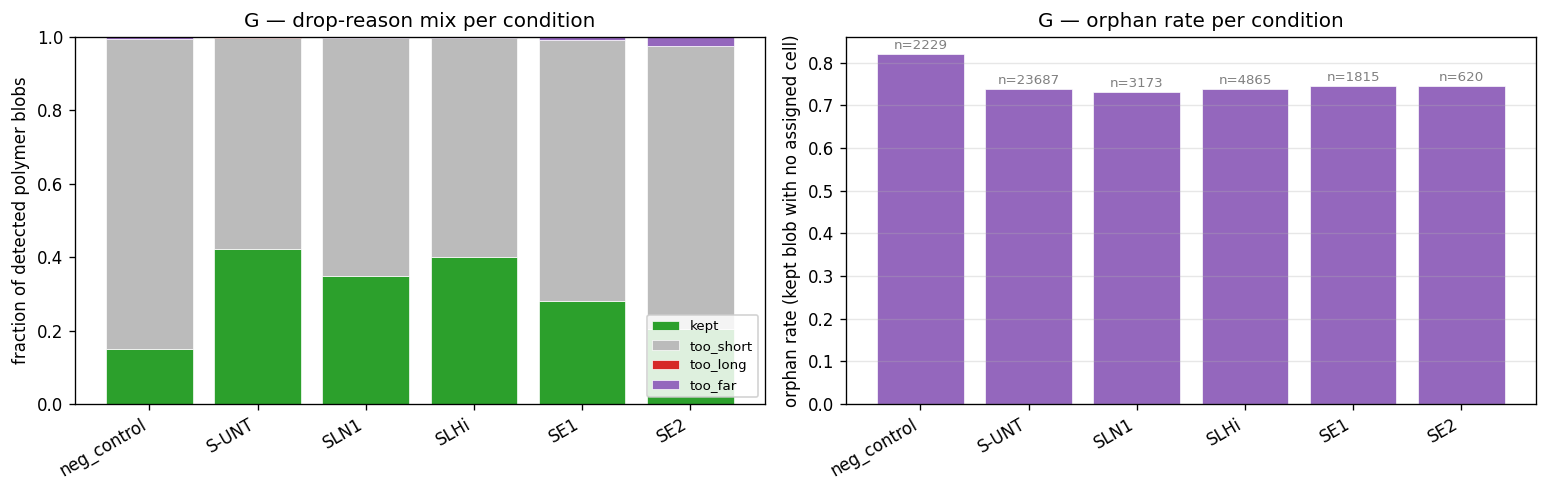

per-group blob QC summary:
      group  n_blobs  kept_frac  orphan_rate
neg_control    14773      0.151        0.820
      S-UNT    56150      0.422        0.738
       SLN1     9083      0.349        0.732
       SLHi    12167      0.400        0.738
        SE1     6454      0.281        0.747
        SE2     3052      0.203        0.745


In [19]:
# === Idea G: QC — drop reasons + orphan rate =============================
# Schema doc (polymer_blobs analysis ideas): drop-reason histograms +
# orphan rate flag imaging/segmentation problems BEFORE drawing
# biological conclusions.
#
# Control panel: the "kept" fraction (large green slice = healthy data).
# A condition that spikes in too_long signals microscopy artifacts; one
# that spikes in too_far signals dust/debris; a high orphan rate flags
# segmentation issues. If everything is clean, this cell is a no-op for
# the biology — and that itself is a useful confirmation.

groups_present = [g for g in CONDITION_ORDER if g in blobs['group'].unique()]
REASON_ORDER  = ['kept', 'too_short', 'too_long', 'too_far']
REASON_COLORS = {'kept': '#2ca02c', 'too_short': '#bbbbbb',
                 'too_long': '#d62728', 'too_far': '#9467bd'}

def _reason(row):
    if row['kept']: return 'kept'
    r = row.get('drop_reason')
    return r if r in REASON_ORDER else 'kept'
blobs = blobs.assign(_reason=blobs.apply(_reason, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=120)

# Stacked bar of drop-reason mix.
ax = axes[0]
xs = np.arange(1, len(groups_present) + 1)
bottom = np.zeros(len(groups_present))
for r in REASON_ORDER:
    fracs = [(blobs[(blobs['group'] == g)]['_reason'] == r).mean()
             if len(blobs[blobs['group'] == g]) else 0.0
             for g in groups_present]
    ax.bar(xs, fracs, bottom=bottom, color=REASON_COLORS[r],
           label=r, edgecolor='white', linewidth=0.4)
    bottom = bottom + np.array(fracs)
ax.set_xticks(xs); ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_ylabel('fraction of detected polymer blobs')
ax.set_title('G — drop-reason mix per condition')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=8, framealpha=0.85)

# Orphan rate among kept blobs.
ax = axes[1]
orphan_rates, kept_counts = [], []
for g in groups_present:
    sub = blobs[(blobs['group'] == g) & blobs['kept']]
    if len(sub):
        orphan_rates.append(float(sub['assigned_instance_id'].isna().mean()))
        kept_counts.append(int(len(sub)))
    else:
        orphan_rates.append(0.0); kept_counts.append(0)
ax.bar(xs, orphan_rates, color='#9467bd', edgecolor='white', linewidth=0.4)
ax.set_xticks(xs); ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_ylabel('orphan rate (kept blob with no assigned cell)')
ax.set_title('G — orphan rate per condition')
ax.grid(alpha=0.3, axis='y')
for x, n, r in zip(xs, kept_counts, orphan_rates):
    ax.text(x, max(r, 0.0) + 0.005, f'n={n}',
            ha='center', va='bottom', fontsize=8, color='gray')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_G_qc.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_G_qc.png', dpi=200, bbox_inches='tight')
plt.show()

print('per-group blob QC summary:')
qc = pd.DataFrame({
    'group':       groups_present,
    'n_blobs':     [int(len(blobs[blobs['group'] == g])) for g in groups_present],
    'kept_frac':   [float((blobs[blobs['group'] == g]['_reason'] == 'kept').mean())
                    if len(blobs[blobs['group'] == g]) else 0.0 for g in groups_present],
    'orphan_rate': orphan_rates,
}).round(3)
print(qc.to_string(index=False))

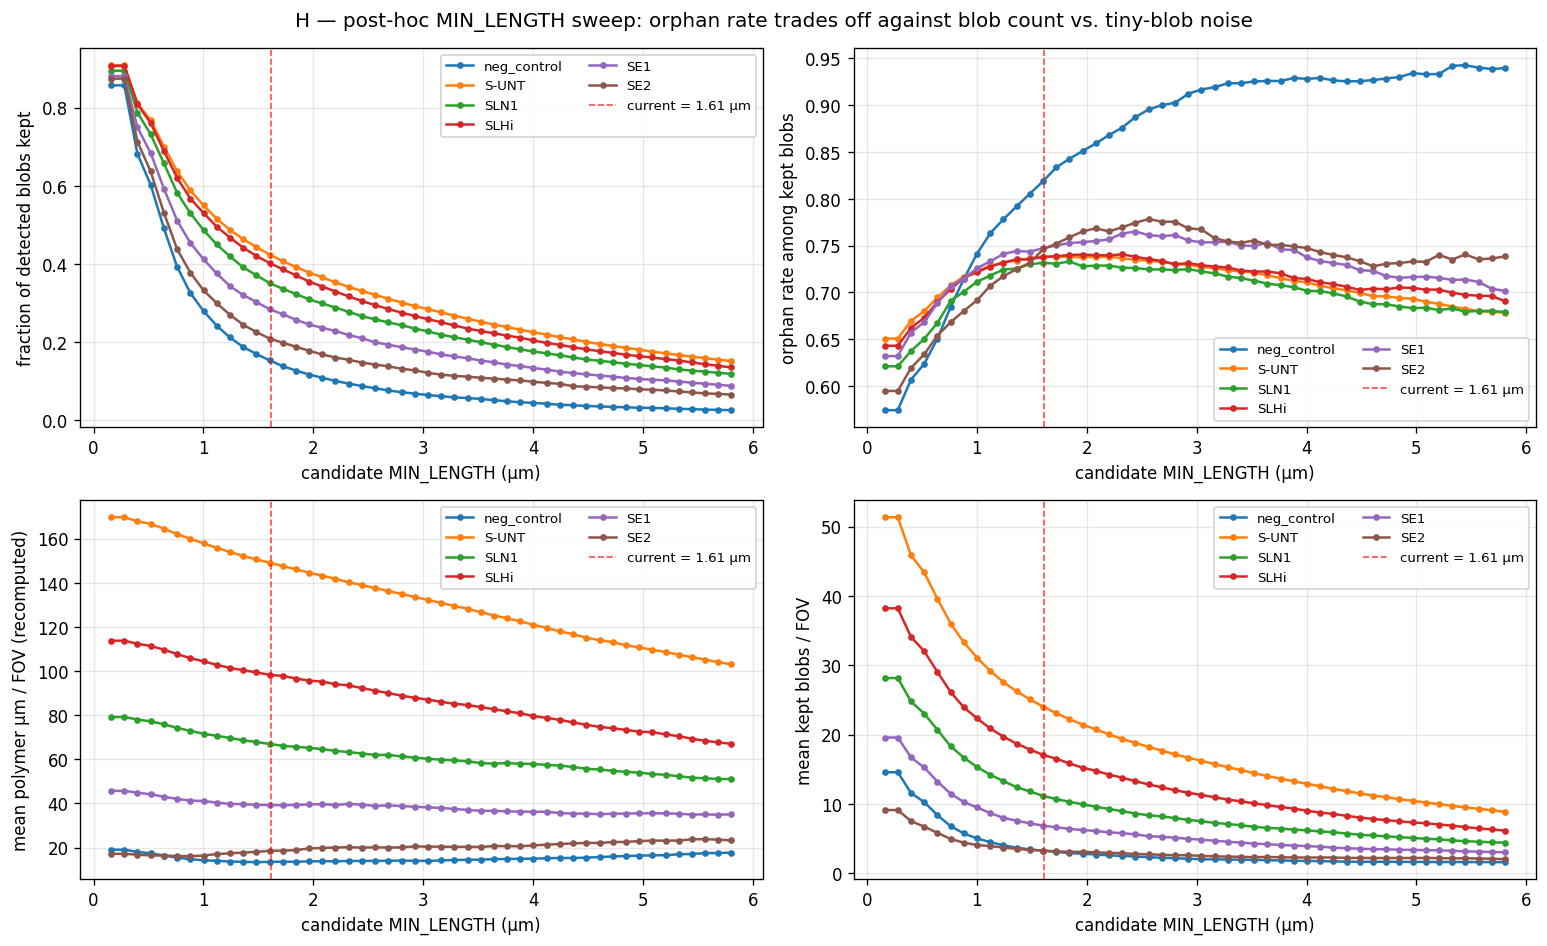


Current MIN_LENGTH = 1.61 µm (= 10 px at 0.161 µm/px).
Snapshots at three thresholds (low / mid / current):
  threshold = 0.160 µm:
      group  kept_frac  orphan_rate  mean_total_um_per_fov  mean_n_kept_per_fov
neg_control      0.857        0.574                 19.046               14.574
      S-UNT      0.909        0.651                169.694               51.350
       SLN1      0.895        0.621                 79.179               28.156
       SLHi      0.907        0.643                113.743               38.215
        SE1      0.881        0.632                 45.696               19.580
        SE2      0.874        0.595                 17.168                9.119
  threshold = 3.043 µm:
      group  kept_frac  orphan_rate  mean_total_um_per_fov  mean_n_kept_per_fov
neg_control      0.065        0.917                 13.960                2.026
      S-UNT      0.284        0.727                132.295               16.219
       SLN1      0.227        0.722        

  threshold = 1.613 µm:
      group  kept_frac  orphan_rate  mean_total_um_per_fov  mean_n_kept_per_fov
neg_control      0.152        0.820                 13.481                3.230
      S-UNT      0.422        0.738                149.036               23.950
       SLN1      0.350        0.732                 66.864               11.133
       SLHi      0.401        0.738                 98.478               17.070
        SE1      0.283        0.747                 39.245                6.849
        SE2      0.209        0.745                 18.497                3.263
wrote: E:\utku g leica\sickling\notebooks\figures\idea_H_min_length_sweep.csv


In [20]:
# === Idea H: post-hoc MIN_LENGTH_PX sweep ================================
# Can the POLYMER_MIN_LENGTH_PX filter be relaxed without re-classifying?
# YES — polymer_blobs.parquet stores EVERY detected blob with its
# `major_um`, `dist_to_cell_px`, `assigned_instance_id` and `drop_reason`,
# so we can re-apply the kept-rule at any threshold and recompute orphan
# rate / total polymer length per FOV from scratch.
#
# Control = the current threshold (red dashed line on every panel —
# inferred from the smallest major_um currently in the kept set; the
# batch_classify default was MIN = 10 px).
#
# What the sweep tests:
#   - kept_frac      : how many of all detected blobs survive
#   - orphan_rate    : fraction of kept blobs with no cell assignment
#   - polymer_um/FOV : sum of major_um of kept blobs per FOV
#   - n_kept_blobs   : blob count per FOV
# Lowering MIN_LENGTH brings back the too_short blobs that already had
# a cell assignment (~46% of them); the other ~54% stay orphan because
# they were too far from any cell — that floor cannot be moved by this
# filter alone.

CURRENT_MIN_LENGTH_UM = float(blobs.loc[blobs['kept'], 'major_um'].min())
PX_TO_UM = CURRENT_MIN_LENGTH_UM / 10.0   # batch_classify uses MIN = 10 px
LENGTH_GRID_UM = np.round(np.linspace(0.16, CURRENT_MIN_LENGTH_UM * 3.6, 48), 3)

# Blobs that ONLY fail too_short are eligible to re-enter when we lower
# the threshold; too_long / too_far stay dropped regardless.
eligible = blobs[(blobs['drop_reason'] != 'too_long') &
                 (blobs['drop_reason'] != 'too_far')].copy()

groups_present = [g for g in CONDITION_ORDER if g in eligible['group'].unique()]
cmap = plt.get_cmap('tab10')

records = []
for thresh in LENGTH_GRID_UM:
    keep = eligible[eligible['major_um'] >= thresh]
    for g in groups_present:
        g_all  = eligible[eligible['group'] == g]
        g_kept = keep[keep['group'] == g]
        if not len(g_all):
            continue
        kept_frac   = float(len(g_kept) / len(g_all))
        orphan_rate = float(g_kept['assigned_instance_id'].isna().mean()) if len(g_kept) else float('nan')
        fov_agg = g_kept.groupby('stem').agg(total_um=('major_um','sum'),
                                              n_kept=('blob_id','size'))
        records.append({
            'threshold_um': float(thresh), 'group': g,
            'kept_frac':    kept_frac,
            'orphan_rate':  orphan_rate,
            'mean_total_um_per_fov': float(fov_agg['total_um'].mean()) if len(fov_agg) else 0.0,
            'mean_n_kept_per_fov':   float(fov_agg['n_kept'].mean())   if len(fov_agg) else 0.0,
        })
sweep_df = pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.0), dpi=120)
panels = [
    (axes[0, 0], 'kept_frac',              'fraction of detected blobs kept'),
    (axes[0, 1], 'orphan_rate',            'orphan rate among kept blobs'),
    (axes[1, 0], 'mean_total_um_per_fov',  'mean polymer µm / FOV (recomputed)'),
    (axes[1, 1], 'mean_n_kept_per_fov',    'mean kept blobs / FOV'),
]
for ax, col, ylabel in panels:
    for i, g in enumerate(groups_present):
        sub = sweep_df[sweep_df['group'] == g].sort_values('threshold_um')
        ax.plot(sub['threshold_um'], sub[col],
                color=cmap(i % 10), linewidth=1.5, marker='o', markersize=3,
                label=g)
    ax.axvline(CURRENT_MIN_LENGTH_UM, color='red', linestyle='--', linewidth=1.0,
               label=f'current = {CURRENT_MIN_LENGTH_UM:.2f} µm', alpha=0.7)
    ax.set_xlabel('candidate MIN_LENGTH (µm)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.85)

fig.suptitle('H — post-hoc MIN_LENGTH sweep: orphan rate trades off '
             'against blob count vs. tiny-blob noise')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_H_min_length_sweep.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_H_min_length_sweep.png', dpi=200, bbox_inches='tight')
plt.show()

print()
print(f'Current MIN_LENGTH = {CURRENT_MIN_LENGTH_UM:.2f} µm '
      f'(= 10 px at {PX_TO_UM:.3f} µm/px).')
print('Snapshots at three thresholds (low / mid / current):')
key_thresholds = [LENGTH_GRID_UM[0],
                  LENGTH_GRID_UM[len(LENGTH_GRID_UM)//2],
                  CURRENT_MIN_LENGTH_UM]
for t in key_thresholds:
    keep = eligible[eligible['major_um'] >= t]
    rows = []
    for g in groups_present:
        g_all  = eligible[eligible['group'] == g]
        g_kept = keep[keep['group'] == g]
        if not len(g_all): continue
        fov_agg = g_kept.groupby('stem').agg(total_um=('major_um','sum'),
                                              n_kept=('blob_id','size'))
        rows.append({
            'group': g,
            'kept_frac':              float(len(g_kept) / len(g_all)),
            'orphan_rate':            float(g_kept['assigned_instance_id'].isna().mean()) if len(g_kept) else float('nan'),
            'mean_total_um_per_fov':  float(fov_agg['total_um'].mean()) if len(fov_agg) else 0.0,
            'mean_n_kept_per_fov':    float(fov_agg['n_kept'].mean())   if len(fov_agg) else 0.0,
        })
    snap = pd.DataFrame(rows)
    print(f'  threshold = {t:.3f} µm:')
    print(snap[['group', 'kept_frac', 'orphan_rate',
                'mean_total_um_per_fov', 'mean_n_kept_per_fov']]
          .round(3).to_string(index=False))

sweep_csv = FIGURES_DIR / 'idea_H_min_length_sweep.csv'
sweep_df.to_csv(sweep_csv, index=False)
print(f'wrote: {sweep_csv}')


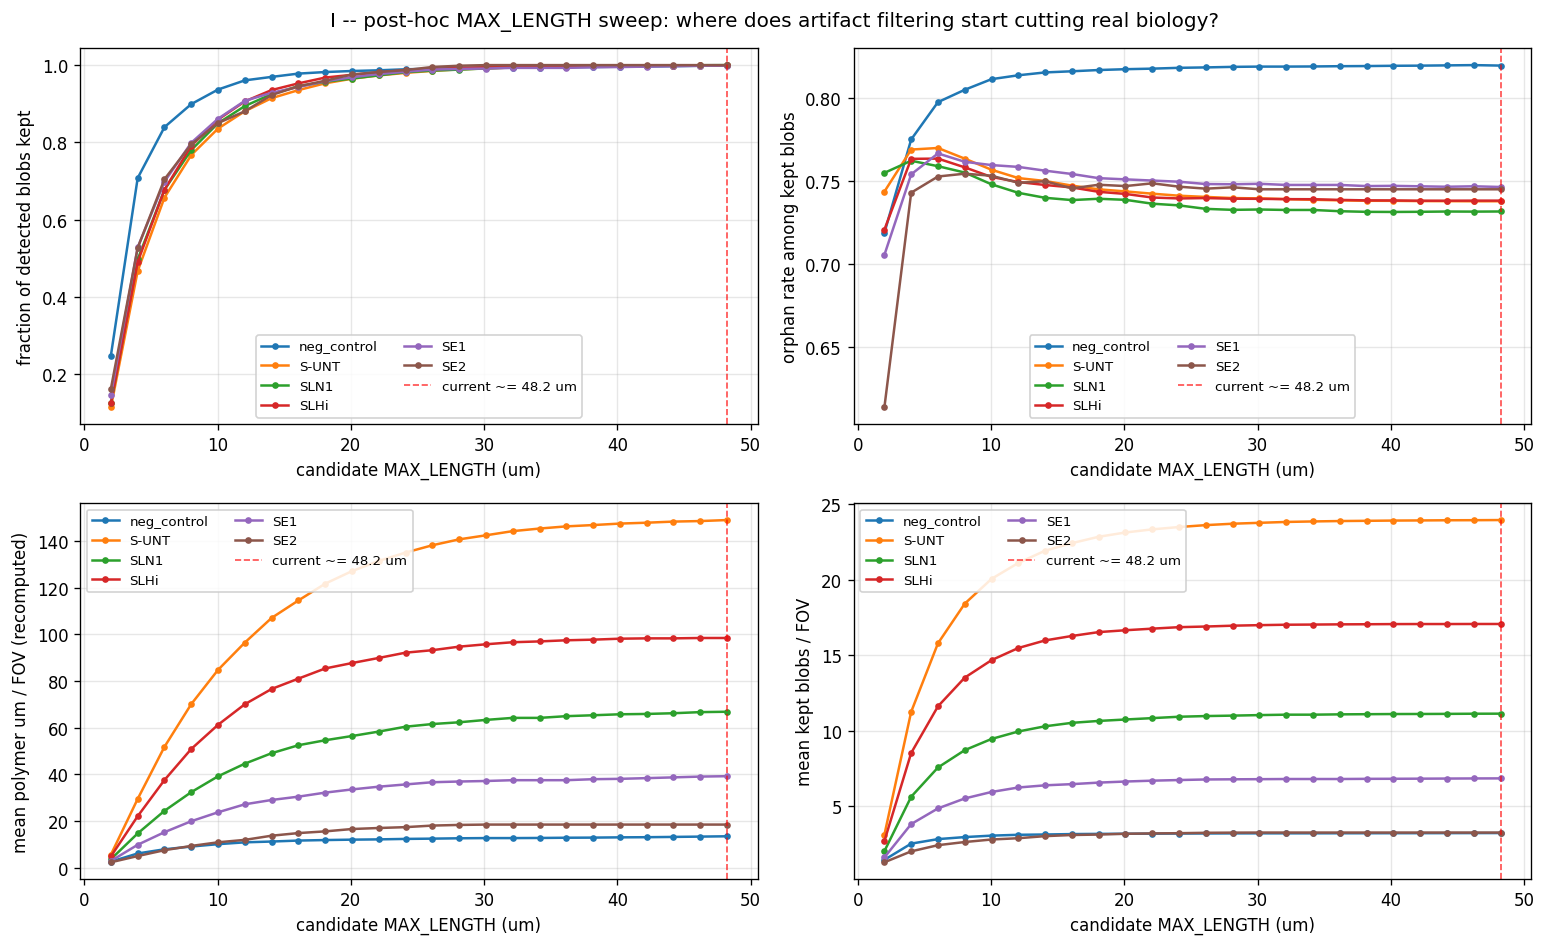


Current MAX_LENGTH = 48.2 um (= 300 px).
Snapshots at three thresholds (tight / mid / current):

  threshold = 2.00 um:
      group  kept_frac  orphan_rate  mean_total_um_per_fov  mean_n_kept_per_fov
neg_control      0.249        0.719                  2.610                1.457
      S-UNT      0.115        0.744                  5.597                3.116
       SLN1      0.125        0.755                  3.652                2.031
       SLHi      0.125        0.721                  4.864                2.695
        SE1      0.146        0.706                  2.903                1.616
        SE2      0.163        0.614                  2.333                1.295

  threshold = 26.12 um:
      group  kept_frac  orphan_rate  mean_total_um_per_fov  mean_n_kept_per_fov
neg_control      0.991        0.819                 12.468                3.203
      S-UNT      0.985        0.741                138.232               23.615
       SLN1      0.986        0.733                 61

In [21]:
# === Idea I: post-hoc POLYMER_MAX_LENGTH_PX sweep ========================
# Sister analysis to H, but at the OTHER end of the length spectrum.
# Current threshold = 300 px ~= 48.4 um (well above any biological fiber).
# Lowering it gradually filters microscope artifacts (saturated long
# streaks, fiber-like dust trails). Going too low starts cutting into
# real long fibers in S-UNT.
#
# Control = the current threshold (red dashed line).
# Sweep range: from 1 um up through the current 48 um, finer near the
# biological tail (most real polymer is <20 um per blob).

CURRENT_MAX_LENGTH_UM = float(blobs[blobs['drop_reason'] != 'too_long']['major_um'].max())
LENGTH_GRID_UM = np.round(np.linspace(2.0, CURRENT_MAX_LENGTH_UM, 24), 2)

# Blobs that only fail too_long would re-enter if we RAISED the limit —
# but the existing 300 px limit only drops 29 blobs total, so the
# meaningful sweep is *lowering* the limit to see when real polymer
# starts disappearing. We treat the original too_long blobs as dropped
# (they would also be dropped at any reasonable lower threshold), and
# vary the upper bound on the kept set.
eligible_I = blobs[blobs['drop_reason'] != 'too_far'].copy()
eligible_I = eligible_I[eligible_I['major_um'] >= CURRENT_MIN_LENGTH_UM].copy()

groups_present = [g for g in CONDITION_ORDER if g in eligible_I['group'].unique()]
cmap = plt.get_cmap('tab10')

records_I = []
for thresh in LENGTH_GRID_UM:
    keep = eligible_I[eligible_I['major_um'] <= thresh]
    for g in groups_present:
        g_all = eligible_I[eligible_I['group'] == g]
        g_kept = keep[keep['group'] == g]
        if not len(g_all):
            continue
        kept_frac = float(len(g_kept) / len(g_all))
        orphan_rate = float(g_kept['assigned_instance_id'].isna().mean()) if len(g_kept) else float('nan')
        fov_agg = g_kept.groupby('stem').agg(total_um=('major_um', 'sum'),
                                              n_kept=('blob_id', 'size'))
        records_I.append({
            'threshold_um': float(thresh), 'group': g,
            'kept_frac': kept_frac,
            'orphan_rate': orphan_rate,
            'mean_total_um_per_fov': float(fov_agg['total_um'].mean()) if len(fov_agg) else 0.0,
            'mean_n_kept_per_fov': float(fov_agg['n_kept'].mean()) if len(fov_agg) else 0.0,
        })
sweep_df_I = pd.DataFrame(records_I)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.0), dpi=120)
panels = [
    (axes[0, 0], 'kept_frac', 'fraction of detected blobs kept'),
    (axes[0, 1], 'orphan_rate', 'orphan rate among kept blobs'),
    (axes[1, 0], 'mean_total_um_per_fov', 'mean polymer um / FOV (recomputed)'),
    (axes[1, 1], 'mean_n_kept_per_fov', 'mean kept blobs / FOV'),
]
for ax, col, ylabel in panels:
    for i, g in enumerate(groups_present):
        sub = sweep_df_I[sweep_df_I['group'] == g].sort_values('threshold_um')
        ax.plot(sub['threshold_um'], sub[col],
                color=cmap(i % 10), linewidth=1.5, marker='o', markersize=3,
                label=g)
    ax.axvline(CURRENT_MAX_LENGTH_UM, color='red', linestyle='--', linewidth=1.0,
               label=f'current ~= {CURRENT_MAX_LENGTH_UM:.1f} um', alpha=0.7)
    ax.set_xlabel('candidate MAX_LENGTH (um)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.85)

fig.suptitle('I -- post-hoc MAX_LENGTH sweep: where does artifact filtering '
             'start cutting real biology?')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_I_max_length_sweep.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_I_max_length_sweep.png', dpi=200, bbox_inches='tight')
plt.show()

print()
print(f'Current MAX_LENGTH = {CURRENT_MAX_LENGTH_UM:.1f} um (= 300 px).')
print('Snapshots at three thresholds (tight / mid / current):')
key_thresholds = [LENGTH_GRID_UM[0], LENGTH_GRID_UM[len(LENGTH_GRID_UM)//2],
                  CURRENT_MAX_LENGTH_UM]
for t in key_thresholds:
    keep = eligible_I[eligible_I['major_um'] <= t]
    rows = []
    for g in groups_present:
        g_all = eligible_I[eligible_I['group'] == g]
        g_kept = keep[keep['group'] == g]
        if not len(g_all):
            continue
        fov_agg = g_kept.groupby('stem').agg(total_um=('major_um', 'sum'),
                                              n_kept=('blob_id', 'size'))
        rows.append({
            'group': g,
            'kept_frac': float(len(g_kept) / len(g_all)),
            'orphan_rate': float(g_kept['assigned_instance_id'].isna().mean()) if len(g_kept) else float('nan'),
            'mean_total_um_per_fov': float(fov_agg['total_um'].mean()) if len(fov_agg) else 0.0,
            'mean_n_kept_per_fov': float(fov_agg['n_kept'].mean()) if len(fov_agg) else 0.0,
        })
    snap = pd.DataFrame(rows)
    print()
    print(f'  threshold = {t:.2f} um:')
    print(snap[['group', 'kept_frac', 'orphan_rate',
                'mean_total_um_per_fov', 'mean_n_kept_per_fov']]
          .round(3).to_string(index=False))

sweep_csv = FIGURES_DIR / 'idea_I_max_length_sweep.csv'
sweep_df_I.to_csv(sweep_csv, index=False)
print()
print(f'wrote: {sweep_csv}')


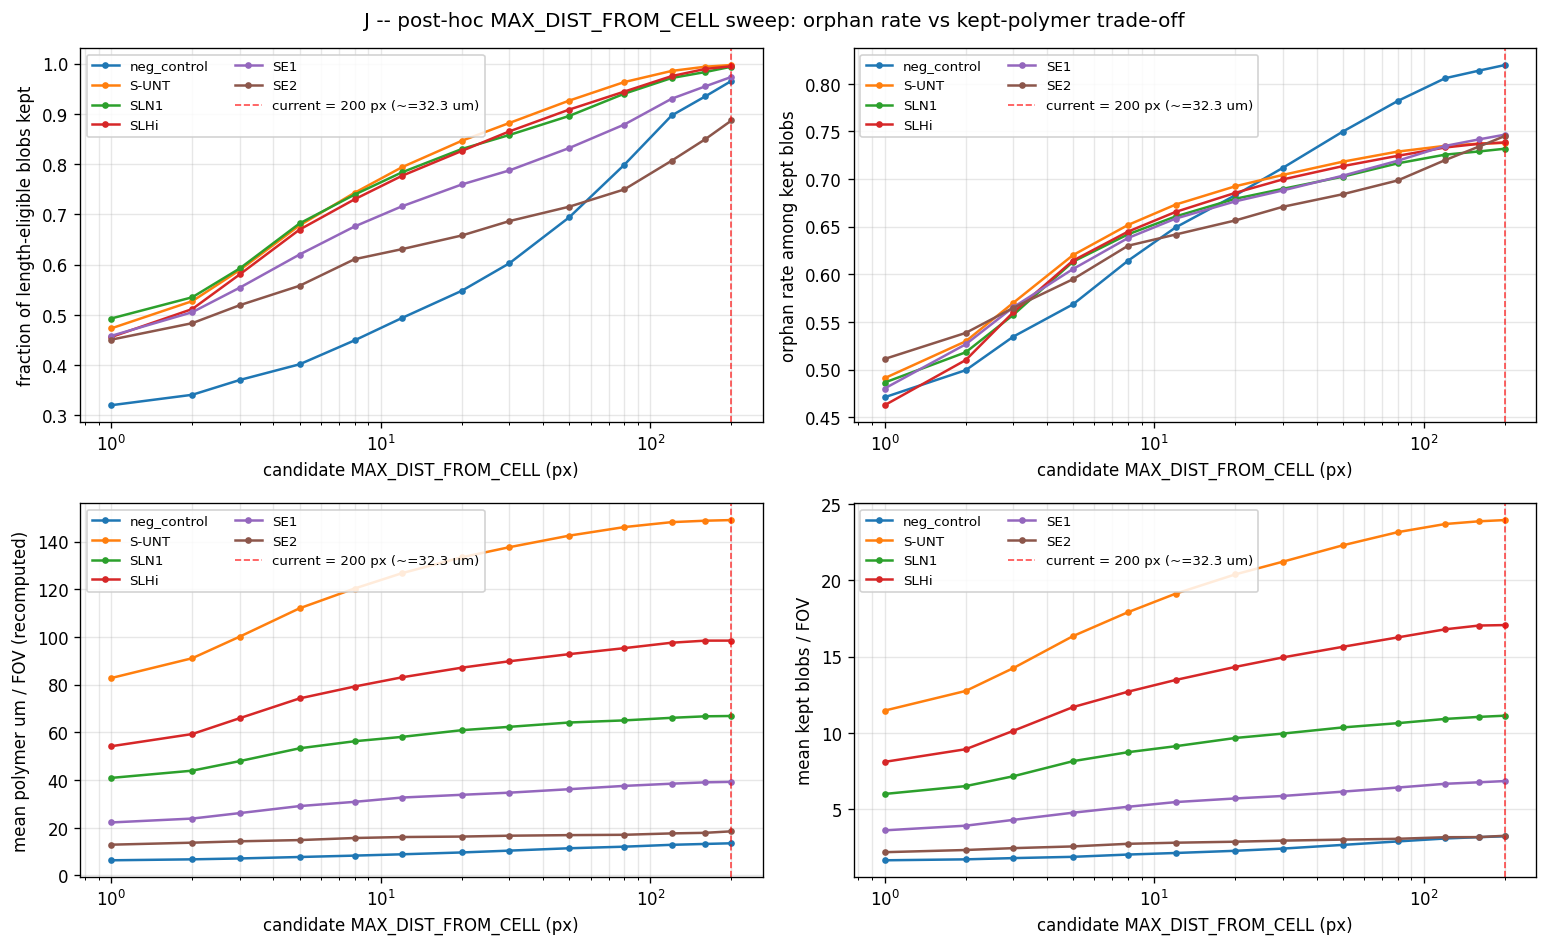


Current MAX_DIST = 200 px (~=32.3 um). Snapshots at three thresholds (tight / mid / current):

  threshold = 5 px (0.81 um):
      group  kept_frac  orphan_rate  mean_total_um_per_fov  mean_n_kept_per_fov
neg_control      0.402        0.569                  7.722                1.884
      S-UNT      0.678        0.620                112.033               16.349
       SLN1      0.682        0.613                 53.317                8.154
       SLHi      0.670        0.614                 74.236               11.696
        SE1      0.620        0.606                 29.081                4.777
        SE2      0.558        0.595                 14.822                2.566

  threshold = 30 px (4.84 um):
      group  kept_frac  orphan_rate  mean_total_um_per_fov  mean_n_kept_per_fov
neg_control      0.603        0.712                 10.397                2.423
      S-UNT      0.882        0.704                137.662               21.223
       SLN1      0.858        0.690       

In [22]:
# === Idea J: post-hoc POLYMER_MAX_DIST_FROM_CELL_PX sweep ================
# THIS is the real answer to "why is orphan rate stuck at ~73%?".
# Current threshold = 200 px ~= 32.3 um (very generous, lets blobs far
# from any cell into the kept set). Most of the orphans came in through
# this loose distance gate, not the length gate H tested.
#
# The polymer_blobs parquet stores dist_to_cell_px per blob, so we can
# re-apply this filter at any value WITHOUT re-segmenting. Sweep range:
# 1 px up through current 200 px. Expectation: lowering MAX_DIST sharply
# reduces orphan rate (orphans had large dist_to_cell_px by construction)
# at the cost of dropping a fraction of true polymer.
#
# Control = the current 200 px threshold (red dashed line).

CURRENT_MAX_DIST_PX = 200.0
PX_TO_UM_J = CURRENT_MIN_LENGTH_UM / 10.0   # reuse same scale derived in H

dist_grid_px = np.unique(np.concatenate([
    np.array([1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120, 160, 200], dtype=float),
])).astype(float)

# Eligible set: blobs that pass the existing length filter (so the sweep
# isolates the distance effect). Drop too_long; keep too_short out so we
# work with the kept-set length range.
eligible_J = blobs[(blobs['major_um'] >= CURRENT_MIN_LENGTH_UM) &
                   (blobs['drop_reason'] != 'too_long')].copy()

groups_present = [g for g in CONDITION_ORDER if g in eligible_J['group'].unique()]
cmap = plt.get_cmap('tab10')

records_J = []
for thresh in dist_grid_px:
    keep = eligible_J[eligible_J['dist_to_cell_px'] <= thresh]
    for g in groups_present:
        g_all = eligible_J[eligible_J['group'] == g]
        g_kept = keep[keep['group'] == g]
        if not len(g_all):
            continue
        kept_frac = float(len(g_kept) / len(g_all))
        orphan_rate = float(g_kept['assigned_instance_id'].isna().mean()) if len(g_kept) else float('nan')
        fov_agg = g_kept.groupby('stem').agg(total_um=('major_um', 'sum'),
                                              n_kept=('blob_id', 'size'))
        records_J.append({
            'threshold_px': float(thresh),
            'threshold_um': float(thresh * PX_TO_UM_J),
            'group': g,
            'kept_frac': kept_frac,
            'orphan_rate': orphan_rate,
            'mean_total_um_per_fov': float(fov_agg['total_um'].mean()) if len(fov_agg) else 0.0,
            'mean_n_kept_per_fov': float(fov_agg['n_kept'].mean()) if len(fov_agg) else 0.0,
        })
sweep_df_J = pd.DataFrame(records_J)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.0), dpi=120)
panels = [
    (axes[0, 0], 'kept_frac', 'fraction of length-eligible blobs kept'),
    (axes[0, 1], 'orphan_rate', 'orphan rate among kept blobs'),
    (axes[1, 0], 'mean_total_um_per_fov', 'mean polymer um / FOV (recomputed)'),
    (axes[1, 1], 'mean_n_kept_per_fov', 'mean kept blobs / FOV'),
]
for ax, col, ylabel in panels:
    for i, g in enumerate(groups_present):
        sub = sweep_df_J[sweep_df_J['group'] == g].sort_values('threshold_px')
        ax.plot(sub['threshold_px'], sub[col],
                color=cmap(i % 10), linewidth=1.5, marker='o', markersize=3,
                label=g)
    ax.axvline(CURRENT_MAX_DIST_PX, color='red', linestyle='--', linewidth=1.0,
               label=f'current = {CURRENT_MAX_DIST_PX:.0f} px '
                     f'(~={CURRENT_MAX_DIST_PX*PX_TO_UM_J:.1f} um)', alpha=0.7)
    ax.set_xlabel('candidate MAX_DIST_FROM_CELL (px)')
    ax.set_xscale('log')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, which='both')
    ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.85)

fig.suptitle('J -- post-hoc MAX_DIST_FROM_CELL sweep: orphan rate vs '
             'kept-polymer trade-off')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_J_max_dist_sweep.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_J_max_dist_sweep.png', dpi=200, bbox_inches='tight')
plt.show()

print()
print(f'Current MAX_DIST = {CURRENT_MAX_DIST_PX:.0f} px '
      f'(~={CURRENT_MAX_DIST_PX*PX_TO_UM_J:.1f} um). Snapshots at three '
      'thresholds (tight / mid / current):')
key_thresholds_px = [5.0, 30.0, CURRENT_MAX_DIST_PX]
for t in key_thresholds_px:
    keep = eligible_J[eligible_J['dist_to_cell_px'] <= t]
    rows = []
    for g in groups_present:
        g_all = eligible_J[eligible_J['group'] == g]
        g_kept = keep[keep['group'] == g]
        if not len(g_all):
            continue
        fov_agg = g_kept.groupby('stem').agg(total_um=('major_um', 'sum'),
                                              n_kept=('blob_id', 'size'))
        rows.append({
            'group': g,
            'kept_frac': float(len(g_kept) / len(g_all)),
            'orphan_rate': float(g_kept['assigned_instance_id'].isna().mean()) if len(g_kept) else float('nan'),
            'mean_total_um_per_fov': float(fov_agg['total_um'].mean()) if len(fov_agg) else 0.0,
            'mean_n_kept_per_fov': float(fov_agg['n_kept'].mean()) if len(fov_agg) else 0.0,
        })
    snap = pd.DataFrame(rows)
    print()
    print(f'  threshold = {t:.0f} px ({t*PX_TO_UM_J:.2f} um):')
    print(snap[['group', 'kept_frac', 'orphan_rate',
                'mean_total_um_per_fov', 'mean_n_kept_per_fov']]
          .round(3).to_string(index=False))

sweep_csv = FIGURES_DIR / 'idea_J_max_dist_sweep.csv'
sweep_df_J.to_csv(sweep_csv, index=False)
print()
print(f'wrote: {sweep_csv}')


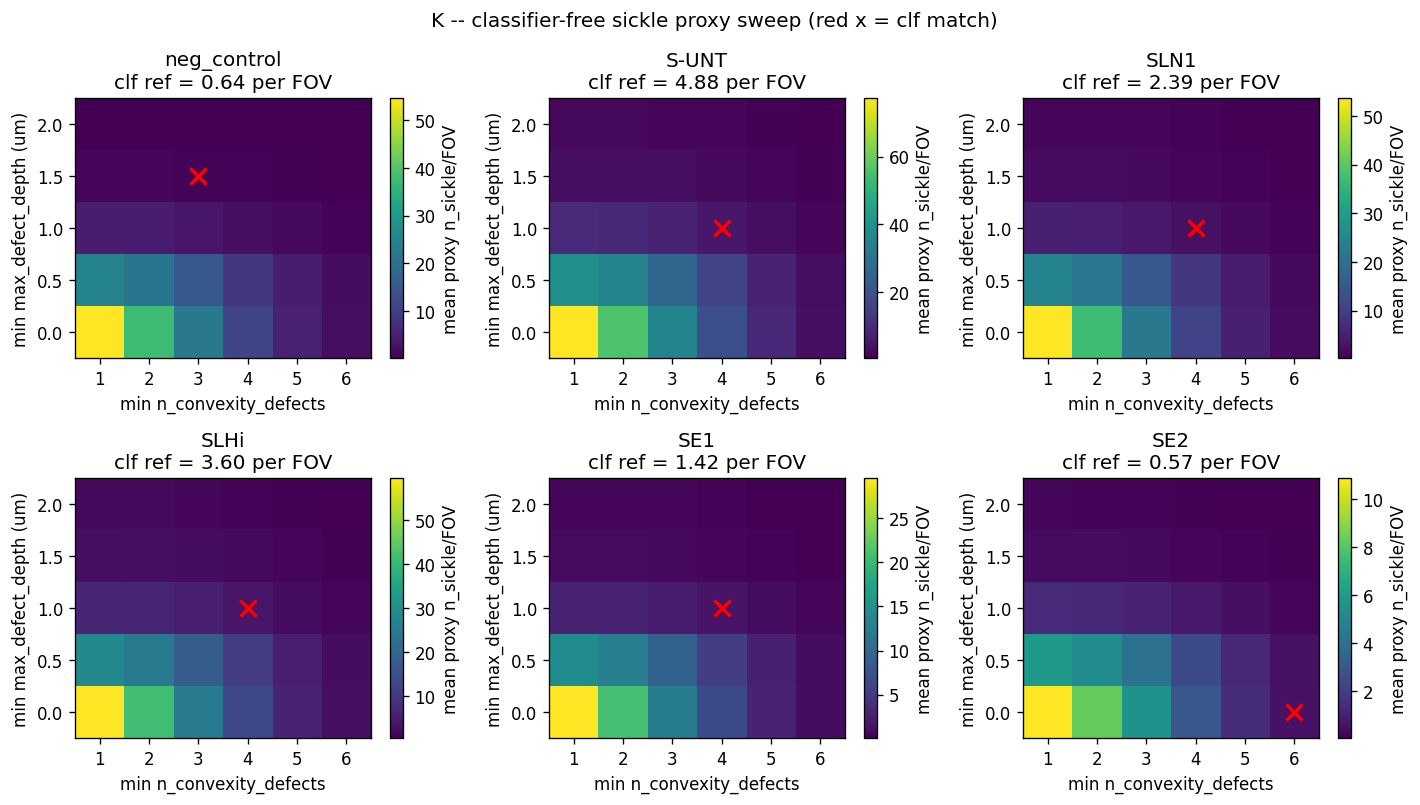


Mean proxy n_sickle per FOV at the current CONVEXITY_MIN_DEFECTS = 2, no depth filter:
neg_control    37.46
S-UNT          55.85
SLN1           37.01
SLHi           41.49
SE1            20.66
SE2             8.34

Mean proxy n_sickle per FOV at a strict (>= 3 defects, >= 1.0 um deep) rule:
neg_control    3.34
S-UNT          7.80
SLN1           3.85
SLHi           5.25
SE1            2.39
SE2            1.09

Classifier reference (fov_df.n_sickle mean per group):
neg_control    0.64
S-UNT          4.88
SLN1           2.39
SLHi           3.60
SE1            1.42
SE2            0.57


In [23]:
# === Idea K: classifier-free sickle proxy with depth filter ==============
# DEFECT_DEPTH_MIN_PX = 2 was applied at extraction time; we CAN'T lower
# it without recomputing (n_convexity_defects is a stored count). But we
# CAN raise the effective bar by ALSO requiring the cell's
# max_defect_depth_um to exceed some value -- that turns "any defect"
# into "at least one DEEP defect", which is more sickle-specific (deep
# crescent notches) vs echinocyte-like (many shallow ripples), per the
# schema doc.
#
# Sweep two thresholds on per_cell:
#   - MIN_DEFECTS in {1, 2, 3, 4, 5, 6}
#   - MIN_DEPTH_UM in {0.0, 0.5, 1.0, 1.5, 2.0}
# Control: the current CONVEXITY_MIN_DEFECTS = 2 with no depth filter
# (top-left of the heatmap). Comparison: the classifier-based n_sickle
# count per FOV (a reference number printed at the bottom).

MIN_DEFECTS_GRID = [1, 2, 3, 4, 5, 6]
MIN_DEPTH_GRID_UM = [0.0, 0.5, 1.0, 1.5, 2.0]

groups_present = [g for g in CONDITION_ORDER if g in per_cell['group'].unique()]

# For each (k_def, d_um), count per-FOV "sickle" cells under the proxy
# rule and aggregate the MEAN per FOV per group. Larger value = more
# permissive proxy = more sickle calls per FOV.
heatmap = np.zeros((len(MIN_DEPTH_GRID_UM), len(MIN_DEFECTS_GRID), len(groups_present)))
for i, d_um in enumerate(MIN_DEPTH_GRID_UM):
    for j, k_def in enumerate(MIN_DEFECTS_GRID):
        mask = ((per_cell['n_convexity_defects'] >= k_def) &
                (per_cell['max_defect_depth_um'] >= d_um))
        pc = per_cell[mask]
        per_fov_counts = pc.groupby(['group', 'stem']).size().reset_index(name='n_proxy_sickle')
        # Reindex over ALL FOVs (zero where no sickle proxies fired).
        full_index = per_cell[['group', 'stem']].drop_duplicates()
        per_fov_counts = full_index.merge(per_fov_counts, on=['group', 'stem'], how='left').fillna({'n_proxy_sickle': 0})
        for g_idx, g in enumerate(groups_present):
            vals = per_fov_counts[per_fov_counts['group'] == g]['n_proxy_sickle'].to_numpy()
            heatmap[i, j, g_idx] = vals.mean() if len(vals) else float('nan')

# Reference: classifier mean n_sickle per FOV per group.
clf_ref = fov_df.groupby('group')['n_sickle'].mean().reindex(groups_present).to_numpy()

# Plot one heatmap per group.
n_groups = len(groups_present)
n_cols = 3
n_rows = int(np.ceil(n_groups / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 3.4 * n_rows), dpi=120)
axes = np.atleast_2d(axes).flatten()
# Shared color scale per group is misleading; use one per panel.
for g_idx, g in enumerate(groups_present):
    ax = axes[g_idx]
    M = heatmap[:, :, g_idx]
    im = ax.imshow(M, aspect='auto', origin='lower', cmap='viridis')
    # Overlay the classifier reference -- find the (k, d) entry whose
    # mean matches clf_ref[g_idx] most closely; mark it.
    flat_diff = np.abs(M - clf_ref[g_idx])
    if np.isfinite(flat_diff).any():
        argmin = np.unravel_index(np.nanargmin(flat_diff), M.shape)
        ax.plot(argmin[1], argmin[0], marker='x', color='red', markersize=10, markeredgewidth=2)
    ax.set_xticks(range(len(MIN_DEFECTS_GRID))); ax.set_xticklabels(MIN_DEFECTS_GRID)
    ax.set_yticks(range(len(MIN_DEPTH_GRID_UM))); ax.set_yticklabels([f'{d:.1f}' for d in MIN_DEPTH_GRID_UM])
    ax.set_xlabel('min n_convexity_defects')
    ax.set_ylabel('min max_defect_depth (um)')
    ax.set_title(f'{g}\nclf ref = {clf_ref[g_idx]:.2f} per FOV')
    plt.colorbar(im, ax=ax, label='mean proxy n_sickle/FOV')
for ax in axes[n_groups:]:
    ax.axis('off')

fig.suptitle('K -- classifier-free sickle proxy sweep (red x = clf match)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_K_defect_proxy_sweep.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_K_defect_proxy_sweep.png', dpi=200, bbox_inches='tight')
plt.show()

print()
print('Mean proxy n_sickle per FOV at the current CONVEXITY_MIN_DEFECTS = 2, no depth filter:')
print(pd.Series(heatmap[0, 1, :], index=groups_present).round(2).to_string())
print()
print('Mean proxy n_sickle per FOV at a strict (>= 3 defects, >= 1.0 um deep) rule:')
strict = heatmap[MIN_DEPTH_GRID_UM.index(1.0), MIN_DEFECTS_GRID.index(3), :]
print(pd.Series(strict, index=groups_present).round(2).to_string())
print()
print('Classifier reference (fov_df.n_sickle mean per group):')
print(pd.Series(clf_ref, index=groups_present).round(2).to_string())


In [24]:
# === Idea L: persist MAX_DIST_FROM_CELL = 10 px to new parquets =========
# Goal: cleaner *biological* polymer measurements. Blobs far from any
# cell are most likely segmentation noise or unrelated objects (free
# debris); excluding them tightens the per-FOV polymer-length signal.
# The lower orphan rate is a side effect, not the target.
#
# What this cell does:
#   1. Recomputes blob-level kept / drop_reason at MAX_DIST = 10 px
#      using the existing major_um and dist_to_cell_px columns.
#   2. Aggregates per-FOV polymer_length_um, n_polymer_blobs_kept,
#      polymer_area_fraction, n_polymer_blobs_dropped_too_far.
#   3. Saves new parquets right next to the originals so the originals
#      stay reproducible:
#         polymer_blobs_dist10.parquet
#         per_fov_dist10.parquet
#      Rename them to drop the _dist10 suffix to make them the canonical
#      inputs going forward.
#   4. Builds in-memory `blobs_d10` and `fov_df_d10` for the next cell.
#
# Skeleton-based columns (polymer_skeleton_length_um, polymer_endpoints,
# polymer_branch_points) are CARRIED OVER UNCHANGED -- they were
# computed once on the original kept-blob mask and can't be recomputed
# without re-running batch_classify on the instance images. If you want
# the skeleton-based metrics at the new threshold, re-run batch_classify.

NEW_MAX_DIST_PX = 10
POLYMER_MIN_LENGTH_PX = 10
POLYMER_MAX_LENGTH_PX = 300
PX_TO_UM_L = 500.0 / 3100.0
MIN_LENGTH_UM = POLYMER_MIN_LENGTH_PX * PX_TO_UM_L
MAX_LENGTH_UM = POLYMER_MAX_LENGTH_PX * PX_TO_UM_L

# --- blob-level: recompute kept / drop_reason vectorized ----------------
blobs_d10 = blobs.copy()
conditions = [
    blobs_d10['major_um'] < MIN_LENGTH_UM,
    blobs_d10['major_um'] > MAX_LENGTH_UM,
    blobs_d10['dist_to_cell_px'] > NEW_MAX_DIST_PX,
]
choices = ['too_short', 'too_long', 'too_far']
blobs_d10['drop_reason'] = np.select(conditions, choices, default='')
blobs_d10['kept'] = (blobs_d10['drop_reason'] == '')

print(f'blob-level transitions ({len(blobs_d10)} blobs total):')
print(f'  was kept, now too_far  : {int(((blobs["kept"]) & (~blobs_d10["kept"])).sum())}')
print(f'  was too_short, still ts: {int((blobs["drop_reason"].eq("too_short") & blobs_d10["drop_reason"].eq("too_short")).sum())}')
print(f'  was too_far, still tf  : {int((blobs["drop_reason"].eq("too_far") & blobs_d10["drop_reason"].eq("too_far")).sum())}')
print(f'  total kept (was -> now): {int(blobs["kept"].sum())} -> {int(blobs_d10["kept"].sum())}')

# --- per-FOV aggregates over the new kept set ---------------------------
new_kept = blobs_d10[blobs_d10['kept']]
fov_agg = (new_kept.groupby('stem')
           .agg(new_polymer_length_um=('major_um', 'sum'),
                new_n_kept=('blob_id', 'size'),
                new_polymer_area_px=('area_px', 'sum'))
           .reset_index())

# Drop counts per stem.
drop_counts = (blobs_d10.groupby(['stem', 'drop_reason']).size()
               .unstack(fill_value=0).reset_index())
for r in ['too_short', 'too_long', 'too_far']:
    if r not in drop_counts.columns:
        drop_counts[r] = 0

# Backsolve cell_tissue_px from the original area_fraction so we can
# recompute the new area_fraction consistently.
# area_frac = polymer_area / (polymer_area + cell_tissue_px)
#   => cell_tissue_px = polymer_area * (1/area_frac - 1)
old_kept_area = blobs[blobs['kept']].groupby('stem')['area_px'].sum()

# Build fov_df_d10.
fov_df_d10 = fov_df.copy()
fov_df_d10 = fov_df_d10.merge(fov_agg, on='stem', how='left')
for c in ['new_polymer_length_um', 'new_n_kept', 'new_polymer_area_px']:
    fov_df_d10[c] = fov_df_d10[c].fillna(0)

fov_df_d10['_old_kept_area_px'] = fov_df_d10['stem'].map(old_kept_area).fillna(0)
with np.errstate(divide='ignore', invalid='ignore'):
    fov_df_d10['_cell_tissue_px'] = (fov_df_d10['_old_kept_area_px']
                                     * (1.0 / fov_df_d10['polymer_area_fraction'].replace(0, np.nan) - 1.0))
fov_df_d10['_cell_tissue_px'] = fov_df_d10['_cell_tissue_px'].fillna(0)

# Overwrite the depends-on-kept-set columns with new values.
fov_df_d10['polymer_length_um']    = fov_df_d10['new_polymer_length_um']
fov_df_d10['n_polymer_blobs_kept'] = fov_df_d10['new_n_kept'].astype(int)
with np.errstate(divide='ignore', invalid='ignore'):
    fov_df_d10['polymer_area_fraction'] = (
        fov_df_d10['new_polymer_area_px']
        / (fov_df_d10['new_polymer_area_px'] + fov_df_d10['_cell_tissue_px']).replace(0, np.nan)
    )
fov_df_d10['polymer_area_fraction'] = fov_df_d10['polymer_area_fraction'].fillna(0)

# Refresh drop-reason counts per FOV.
drop_counts_idx = drop_counts.set_index('stem')
for r in ['too_short', 'too_long', 'too_far']:
    col = f'n_polymer_blobs_dropped_{r}'
    fov_df_d10[col] = fov_df_d10['stem'].map(drop_counts_idx[r]).fillna(0).astype(int)

# Recompute normalized polymer metrics from the new polymer_length_um.
with np.errstate(divide='ignore', invalid='ignore'):
    fov_df_d10['polymer_um_per_100_cells'] = (
        fov_df_d10['polymer_length_um'] * 100.0 / fov_df_d10['n_cells'].replace(0, np.nan)
    )
    fov_df_d10['polymer_um_per_100_sickle_cells'] = (
        fov_df_d10['polymer_length_um'] * 100.0 / fov_df_d10['n_sickle'].replace(0, np.nan)
    )

# Tidy up helper columns.
fov_df_d10 = fov_df_d10.drop(columns=[
    'new_polymer_length_um', 'new_n_kept', 'new_polymer_area_px',
    '_old_kept_area_px', '_cell_tissue_px',
])

# --- write parquets -----------------------------------------------------
blobs_d10_path = EXPERIMENT_DATA / 'polymer_blobs_dist10.parquet'
fov_d10_path   = EXPERIMENT_DATA / 'per_fov_dist10.parquet'
# Drop transient helper columns from blobs_d10 that we added during analysis
# in earlier cells (e.g. `group`, `_reason`).
blobs_to_save = blobs_d10.drop(columns=[c for c in ('group', '_reason')
                                        if c in blobs_d10.columns])
blobs_to_save.to_parquet(blobs_d10_path, index=False)
fov_to_save = fov_df_d10.drop(columns=[c for c in ('group',)
                                        if c in fov_df_d10.columns])
fov_to_save.to_parquet(fov_d10_path, index=False)
print()
print(f'wrote: {blobs_d10_path}')
print(f'wrote: {fov_d10_path}')

# --- before/after summary ----------------------------------------------
print()
print('per-condition mean polymer_length_um (MAX_DIST 200 -> 10):')
print(f'  {"group":11s} {"old":>8s} {"new":>8s} {"ratio":>7s}')
for g in [g for g in CONDITION_ORDER if g in fov_df['group'].unique()]:
    old = fov_df[fov_df['group'] == g]['polymer_length_um'].mean()
    new = fov_df_d10[fov_df_d10['group'] == g]['polymer_length_um'].mean()
    print(f'  {g:11s} {old:>8.2f} {new:>8.2f} {new/old if old else float("nan"):>7.2f}')


blob-level transitions (101679 blobs total):
  was kept, now too_far  : 9038
  was too_short, still ts: 64947
  was too_far, still tf  : 314
  total kept (was -> now): 36389 -> 27351



wrote: E:\utku g leica\sickling\rbc_classification\experiment_data\polymer_blobs_dist10.parquet
wrote: E:\utku g leica\sickling\rbc_classification\experiment_data\per_fov_dist10.parquet

per-condition mean polymer_length_um (MAX_DIST 200 -> 10):
  group            old      new   ratio


  neg_control    10.77     5.20    0.48
  S-UNT         148.59   123.42    0.83
  SLN1           66.17    54.26    0.82
  SLHi           97.45    79.85    0.82
  SE1            36.11    27.15    0.75
  SE2            12.20     8.70    0.71


MAX_DIST = 10 px regen - source: major_axis (polymer_length_um)  den: classifier (n_sickle)
  group        n_kept  n_excl     mean       q1       q3  sickle_frac
  neg_control     302      35     2.84     0.00     4.42       0.0090
  S-UNT           715      36    23.66    16.37    30.83       0.0503
  SLN1            116       6    19.45    13.52    25.23       0.0343
  SLHi            166       6    20.59    13.24    27.10       0.0460
  SE1              49       1    14.49     9.91    20.46       0.0374
  SE2              12       0     9.48     3.40    16.53       0.0440


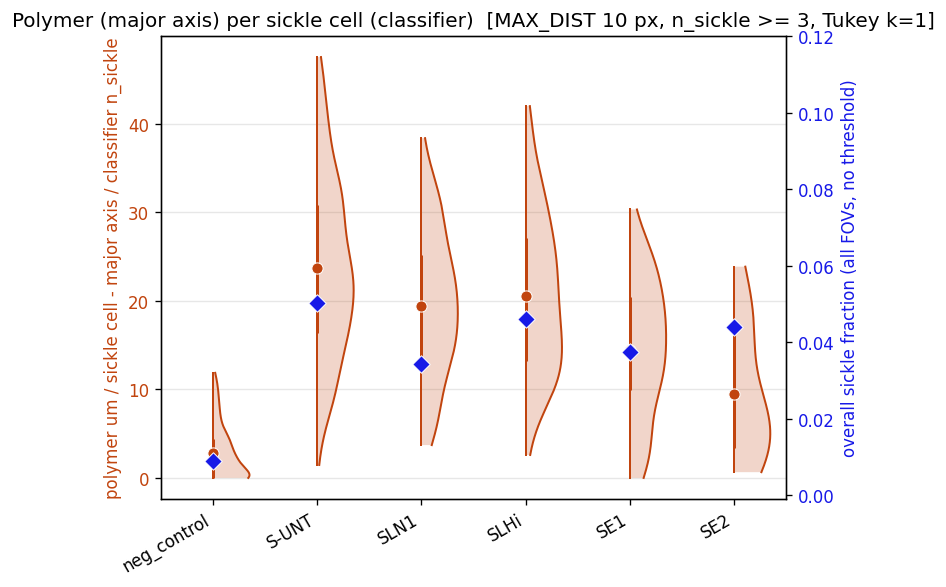

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition_dist10.svg
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition_dist10.png


In [25]:
# === Half-violin paper figure regenerated at MAX_DIST = 10 px ============
# Mirrors the paper_figure cell exactly but consumes fov_df_d10 instead
# of fov_df. Same toggles (POLYMER_LENGTH_SOURCE, SICKLE_COUNT_SOURCE,
# APPLY_TUKEY, TUKEY_K, PLOT_STYLE) and same filtering pipeline
# (MIN_SICKLE skip-for-neg_control, MAX_CELLS).
#
# Output figure: sickle_polymer_per_condition_dist10.{svg,png}.

# Apply BOTH thresholds (same logic as pick_threshold + pick_max_cells)
# but on fov_df_d10.
_pass_min_sickle = (
    (fov_df_d10['n_sickle'] >= MIN_SICKLE)
    | fov_df_d10['group'].isin(SKIP_MIN_SICKLE_FOR)
)
kept_df_d10 = fov_df_d10[_pass_min_sickle].copy()
kept_df_d10 = kept_df_d10[kept_df_d10['n_cells'] <= MAX_CELLS].copy()

# `n_sickle_conv` was already merged on stem in compute_metric, so it's
# present on fov_df_d10 via the .copy() chain; but if MAX_DIST changed
# the per-FOV mapping nothing happened (convexity defects are per_cell,
# unaffected). n_sickle_soft = mean_p_sickle * n_cells likewise unchanged.

_LEN_COL = {
    'major_axis': 'polymer_length_um',
    'skeleton':   'polymer_skeleton_length_um',
}[POLYMER_LENGTH_SOURCE]
_SOURCE_LABEL = {
    'major_axis': 'major axis',
    'skeleton':   'skeleton',
}[POLYMER_LENGTH_SOURCE]
_DEN_COL = {
    'classifier':      'n_sickle',
    'soft_classifier': 'n_sickle_soft',
    'convexity':       'n_sickle_conv',
}[SICKLE_COUNT_SOURCE]
_DEN_LABEL = {
    'classifier':      'classifier n_sickle',
    'soft_classifier': 'soft classifier mean_p*n_cells',
    'convexity':       f'convexity >= {CONVEXITY_MIN_DEFECTS} (clf-free)',
}[SICKLE_COUNT_SOURCE]

groups_present = [g for g in CONDITION_ORDER if g in kept_df_d10['group'].unique()]
raw_by_group = []
for g in groups_present:
    sub = kept_df_d10[(kept_df_d10['group'] == g) & (kept_df_d10[_DEN_COL] > 0)]
    vals = (sub[_LEN_COL] / sub[_DEN_COL]).dropna().to_numpy()
    raw_by_group.append(vals)

if APPLY_TUKEY:
    plot_by_group = [_tukey_keep(v, TUKEY_K) for v in raw_by_group]
else:
    plot_by_group = raw_by_group
n_excluded = [int(r.size - p.size) for r, p in zip(raw_by_group, plot_by_group)]

sickle_frac = []
for g in groups_present:
    sub_all = fov_df_d10[fov_df_d10['group'] == g]
    total_sickle = float(sub_all['n_sickle'].sum())
    total_cells  = float(sub_all['n_cells'].sum())
    sickle_frac.append(total_sickle / total_cells if total_cells > 0 else float('nan'))

rng = np.random.default_rng(0)
fig_w = max(5.0, 1.1 * len(groups_present))
fig, ax = plt.subplots(figsize=(fig_w, 5.0), dpi=120)

for i, (g, vals) in enumerate(zip(groups_present, plot_by_group)):
    x = i + 1
    if vals.size == 0:
        continue
    if PLOT_STYLE == 'half_violin':
        _draw_half_violin(ax, x, vals, side=VIOLIN_SIDE, half_width=VIOLIN_HALF_WIDTH,
                          fill=VIOLIN_FILL, border=VIOLIN_BORDER)
    else:
        jitter = rng.uniform(-JITTER, JITTER, size=vals.size)
        ax.scatter(np.full_like(vals, x) + jitter, vals,
                   s=22, color='black', alpha=0.35, edgecolors='none', zorder=2)
    mean_val = float(np.mean(vals))
    q1, q3 = float(np.quantile(vals, 0.25)), float(np.quantile(vals, 0.75))
    ax.plot([x, x], [q1, q3], color=MEAN_DOT_COLOR, linewidth=1.8, zorder=4, solid_capstyle='butt')
    ax.scatter([x], [mean_val], color=MEAN_DOT_COLOR, s=45, zorder=5,
               edgecolors='white', linewidths=0.6)

ax.set_xticks(range(1, len(groups_present) + 1))
ax.set_xticklabels(groups_present, rotation=30, ha='right')
ax.set_xlim(0.5, len(groups_present) + 0.5)
ax.set_ylabel(f'polymer um / sickle cell - {_SOURCE_LABEL} / {_DEN_LABEL}',
              color=VIOLIN_BORDER)
ax.tick_params(axis='y', labelcolor=VIOLIN_BORDER)
tukey_tag = f', Tukey k={TUKEY_K:g}' if APPLY_TUKEY else ''
ax.set_title(f'Polymer ({_SOURCE_LABEL}) per sickle cell ({SICKLE_COUNT_SOURCE})  '
             f'[MAX_DIST 10 px, n_sickle >= {MIN_SICKLE}{tukey_tag}]')
ax.grid(alpha=0.3, axis='y')

ax2 = ax.twinx()
xs2 = np.arange(1, len(groups_present) + 1)
ax2.scatter(xs2, sickle_frac, color=SICKLE_FRAC_COLOR,
            s=55, marker='D', zorder=6,
            edgecolors='white', linewidths=0.6, label='overall sickle fraction')
ax2.set_ylim(-0.001, 0.12) # *SICKLE_FRAC_YLIM to match previous plot
ax2.set_ylabel('overall sickle fraction (all FOVs, no threshold)', color=SICKLE_FRAC_COLOR)
ax2.tick_params(axis='y', labelcolor=SICKLE_FRAC_COLOR)

print(f'MAX_DIST = 10 px regen - source: {POLYMER_LENGTH_SOURCE} ({_LEN_COL})  '
      f'den: {SICKLE_COUNT_SOURCE} ({_DEN_COL})')
print(f'  {"group":11s} {"n_kept":>7} {"n_excl":>7} {"mean":>8} {"q1":>8} {"q3":>8} {"sickle_frac":>12}')
for g, raw, plot, exc, sf in zip(groups_present, raw_by_group, plot_by_group, n_excluded, sickle_frac):
    if plot.size:
        print(f'  {g:11s} {plot.size:>7d} {exc:>7d} '
              f'{np.mean(plot):>8.2f} {np.quantile(plot,0.25):>8.2f} '
              f'{np.quantile(plot,0.75):>8.2f} {sf:>12.4f}')
    else:
        print(f'  {g:11s} {0:>7d} {exc:>7d}   ----   ----   ----  {sf:>12.4f}')

fig.tight_layout()
pf_svg = FIGURES_DIR / 'sickle_polymer_per_condition_dist10.svg'
pf_png = FIGURES_DIR / 'sickle_polymer_per_condition_dist10.png'
fig.savefig(pf_svg, bbox_inches='tight')
fig.savefig(pf_png, dpi=200, bbox_inches='tight')
plt.show()
print(f'wrote: {pf_svg}')
print(f'wrote: {pf_png}')


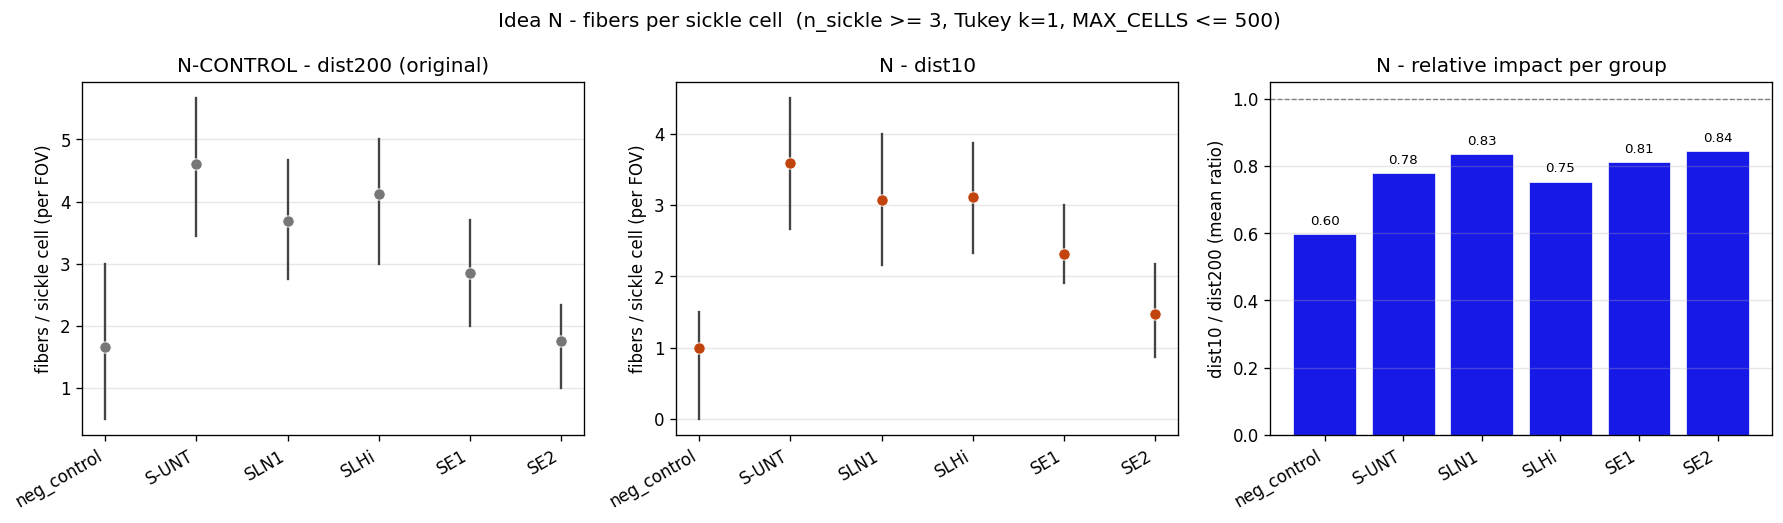

Mean fibers per sickle cell, dist200 vs dist10 (after Tukey k=1):
      group  n_orig  n_dist10  mean_orig  mean_dist10  ratio
neg_control     301       326      1.662        0.991  0.596
      S-UNT     704       709      4.597        3.584  0.780
       SLN1     115       118      3.683        3.075  0.835
       SLHi     160       158      4.121        3.106  0.754
        SE1      47        47      2.854        2.313  0.811
        SE2      11        11      1.750        1.477  0.844

Pairwise Mann-Whitney vs neg_control (dist10 fibers/sickle):
      group   n  median      p_raw       p_bh
neg_control 326       1        NaN        NaN
      S-UNT 709     3.5 7.493e-117 3.747e-116
       SLN1 118       3  6.379e-41  1.063e-40
       SLHi 158       3  4.537e-52  1.134e-51
        SE1  47   2.333  2.295e-14  2.868e-14
        SE2  11     1.5    0.05204    0.05204
wrote: E:\utku g leica\sickling\notebooks\figures\idea_N_fibers_per_sickle.csv


In [26]:
# === Idea N: fibers per sickle cell (dist200 vs dist10) =================
# Schema doc fiber-count proxies:
#   - polymer_endpoints / 2 (skeleton-derived; used in idea A)
#   - n_polymer_blobs_kept (connected-component-derived; idea L recomputed
#                           this at MAX_DIST = 10 px)
#
# We use n_polymer_blobs_kept because, unlike polymer_endpoints, it can
# be recomputed post-hoc from polymer_blobs after a threshold change.
# One kept polymer connected-component ~= one fiber.
#
# Metric: per-FOV fibers_per_sickle = n_polymer_blobs_kept / n_sickle.
# Applied to the same FOV set the paper figure uses
# (MIN_SICKLE skip-for-neg_control, MAX_CELLS).
#
# Three views side by side:
#   Left   : dist200 (original) — CONTROL
#   Middle : dist10  (idea L)   — main view
#   Right  : ratio dist10 / dist200 per group — direct relative impact
#
# Interpretation: if the dist10 / dist200 ratio is well below 1, that
# group had a lot of far-from-cell blobs feeding its fiber count -- those
# were likely segmentation noise / debris, and the cleaned number is a
# more biologically meaningful "fibers per sickle cell".

import scipy.stats as _stats_N

def _fibers_per_sickle(df):
    sub = df[df['n_sickle'] > 0]
    return (sub['n_polymer_blobs_kept'].astype(float) / sub['n_sickle']).dropna().to_numpy()

# Build kept_df (dist200) using the SAME filter logic as pick_threshold
# + pick_max_cells, so this cell is self-contained even if you only ran
# the supplementary section out of order.
_pass = ((fov_df['n_sickle'] >= MIN_SICKLE)
         | fov_df['group'].isin(SKIP_MIN_SICKLE_FOR))
kept_df_orig = fov_df[_pass & (fov_df['n_cells'] <= MAX_CELLS)].copy()
_pass = ((fov_df_d10['n_sickle'] >= MIN_SICKLE)
         | fov_df_d10['group'].isin(SKIP_MIN_SICKLE_FOR))
kept_df_dist10 = fov_df_d10[_pass & (fov_df_d10['n_cells'] <= MAX_CELLS)].copy()

groups_present = [g for g in CONDITION_ORDER if g in kept_df_orig['group'].unique()]

# Collect Tukey-filtered values per group for both datasets.
rows = []
for g in groups_present:
    v_o = _fibers_per_sickle(kept_df_orig[kept_df_orig['group'] == g])
    v_d = _fibers_per_sickle(kept_df_dist10[kept_df_dist10['group'] == g])
    if APPLY_TUKEY:
        v_o = _tukey_keep(v_o, TUKEY_K)
        v_d = _tukey_keep(v_d, TUKEY_K)
    rows.append({
        'group': g,
        'n_orig':  int(v_o.size),
        'n_dist10': int(v_d.size),
        'mean_orig':  float(np.mean(v_o)) if v_o.size else float('nan'),
        'mean_dist10': float(np.mean(v_d)) if v_d.size else float('nan'),
        'q1_orig':  float(np.quantile(v_o, 0.25)) if v_o.size else float('nan'),
        'q3_orig':  float(np.quantile(v_o, 0.75)) if v_o.size else float('nan'),
        'q1_dist10': float(np.quantile(v_d, 0.25)) if v_d.size else float('nan'),
        'q3_dist10': float(np.quantile(v_d, 0.75)) if v_d.size else float('nan'),
        'vals_orig':  v_o,
        'vals_dist10': v_d,
    })
fps_df = pd.DataFrame(rows)
fps_df['ratio'] = fps_df['mean_dist10'] / fps_df['mean_orig']

# ----- draw three panels -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), dpi=120)

def _draw(ax, value_col, title, ylabel, color):
    for i, row in fps_df.iterrows():
        vals = row[value_col]
        if not len(vals):
            continue
        x = i + 1
        q1, q3 = np.quantile(vals, [0.25, 0.75])
        ax.plot([x, x], [q1, q3], color='#444', linewidth=1.4, zorder=3)
        ax.scatter([x], [np.mean(vals)], color=color, s=46, zorder=5,
                   edgecolors='white', linewidths=0.5)
    ax.set_xticks(range(1, len(fps_df) + 1))
    ax.set_xticklabels(fps_df['group'], rotation=30, ha='right')
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')

_draw(axes[0], 'vals_orig',
      'N-CONTROL - dist200 (original)',
      'fibers / sickle cell (per FOV)',
      '#777')
_draw(axes[1], 'vals_dist10',
      'N - dist10',
      'fibers / sickle cell (per FOV)',
      '#c1440eff')

# Ratio panel.
ax = axes[2]
xs = np.arange(1, len(fps_df) + 1)
ax.bar(xs, fps_df['ratio'], color='#1719e7ff', edgecolor='white', linewidth=0.4)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticks(xs); ax.set_xticklabels(fps_df['group'], rotation=30, ha='right')
ax.set_ylim(0, max(1.05, fps_df['ratio'].max() * 1.1))
ax.set_ylabel('dist10 / dist200 (mean ratio)')
ax.set_title('N - relative impact per group')
ax.grid(alpha=0.3, axis='y')
for x, r in zip(xs, fps_df['ratio']):
    ax.text(x, r + 0.02, f'{r:.2f}', ha='center', va='bottom', fontsize=8)

tukey_tag = f', Tukey k={TUKEY_K:g}' if APPLY_TUKEY else ''
fig.suptitle(f'Idea N - fibers per sickle cell  (n_sickle >= {MIN_SICKLE}'
             f'{tukey_tag}, MAX_CELLS <= {MAX_CELLS})')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idea_N_fibers_per_sickle.svg', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'idea_N_fibers_per_sickle.png', dpi=200, bbox_inches='tight')
plt.show()

# ----- summary table -----
summary = fps_df[['group', 'n_orig', 'n_dist10',
                  'mean_orig', 'mean_dist10', 'ratio']].copy()
print('Mean fibers per sickle cell, dist200 vs dist10 (after Tukey k=1):')
print(summary.round(3).to_string(index=False))

# ----- pairwise Mann-Whitney vs neg_control on dist10 -----
ref = fps_df[fps_df['group'] == 'neg_control']['vals_dist10'].iloc[0]
mw_rows = []
for _, row in fps_df.iterrows():
    g = row['group']
    v = row['vals_dist10']
    if g == 'neg_control' or len(v) < 2 or len(ref) < 2:
        p = float('nan')
    else:
        p = float(_stats_N.mannwhitneyu(v, ref, alternative='two-sided').pvalue)
    mw_rows.append({'group': g, 'n': int(len(v)),
                    'median': float(np.median(v)) if len(v) else float('nan'),
                    'p_raw': p})
mw_df = pd.DataFrame(mw_rows)
ps = mw_df['p_raw'].to_numpy(); m = ~np.isnan(ps)
p = ps[m]; order = np.argsort(p); n = p.size
adj_sorted = p[order] * n / np.arange(1, n + 1)
adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
adj_sorted = np.clip(adj_sorted, 0, 1)
adj = np.full(n, np.nan); adj[order] = adj_sorted
bh = np.full_like(ps, np.nan); bh[m] = adj
mw_df['p_bh'] = bh
print()
print('Pairwise Mann-Whitney vs neg_control (dist10 fibers/sickle):')
print(mw_df.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

summary_csv = FIGURES_DIR / 'idea_N_fibers_per_sickle.csv'
summary.to_csv(summary_csv, index=False)
print(f'wrote: {summary_csv}')


---

## 🎯 Paper Figure 2e — pool statistics per condition

This cell (**Idea O**) produces the paper's main biology figure. Pool statistics per condition:

> `mean protrusion length per sickle cell = sum(polymer_length_um) / sum(n_sickle)`  across all FOVs, no MIN_SICKLE per-FOV filter (the pool ratio is not sensitive to per-FOV denominator volatility). The upper bound `MAX_CELLS ≤ 500` is still applied as a biological-cleanliness filter (see Idea L for MAX_DIST derivation).

Bootstrap 95% CIs over 1000 FOV resamples. Output CSV matches the paper's cited numbers exactly (HbAA 8.1 µm, HbSS 25.3 µm, LNP 22.2–22.7 µm, EP 15.3–19.1 µm).


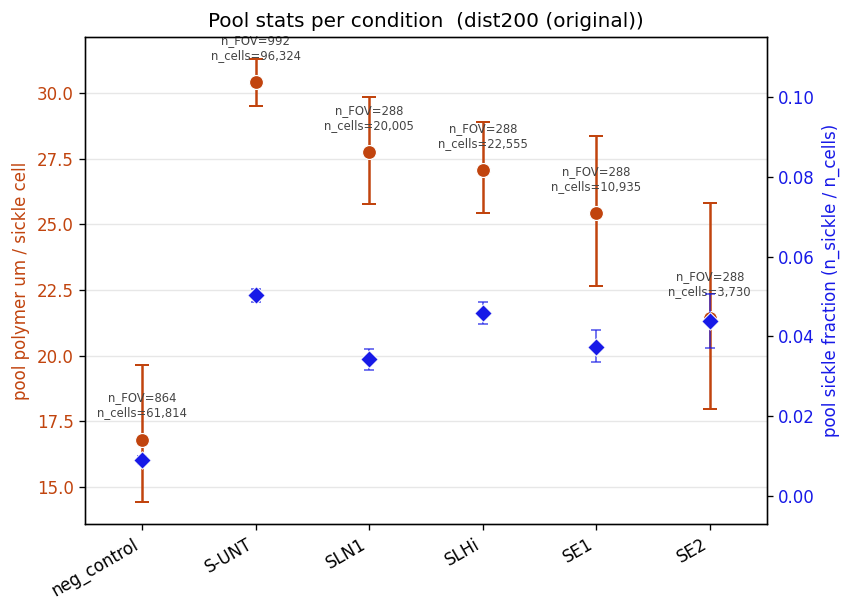

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition_pool.svg
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition_pool.png


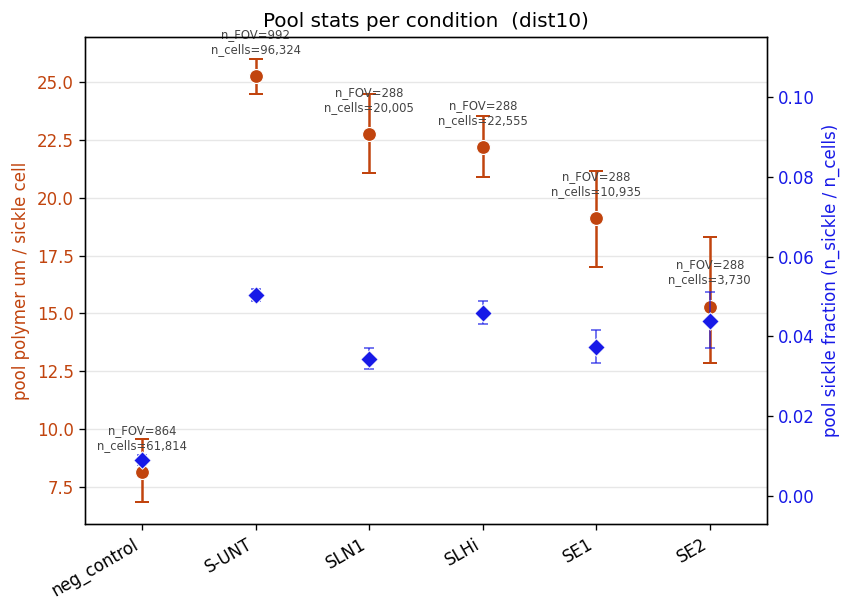

wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition_pool_dist10.svg
wrote: E:\utku g leica\sickling\notebooks\figures\sickle_polymer_per_condition_pool_dist10.png

POOL stats per condition  (dist200 (original), MAX_CELLS <= 500, NO MIN_SICKLE):
  group        n_FOVs   n_cells  n_sickle  sickle_%   um/sickle            95% CI
  neg_control     864    61,814       554     0.90%      16.79    [14.43, 19.65]
  S-UNT           992    96,324     4,845     5.03%      30.42    [29.51, 31.29]
  SLN1            288    20,005       687     3.43%      27.74    [25.78, 29.84]
  SLHi            288    22,555     1,037     4.60%      27.06    [25.44, 28.89]
  SE1             288    10,935       409     3.74%      25.43    [22.63, 28.36]
  SE2             288     3,730       164     4.40%      21.43    [17.97, 25.80]

POOL stats per condition  (dist10 (MAX_DIST = 10 px), MAX_CELLS <= 500, NO MIN_SICKLE):
  group        n_FOVs   n_cells  n_sickle  sickle_%   um/sickle        

In [27]:
# === Idea O: pool-level sickle_polymer_per_condition ====================
# Per-FOV ratios (polymer_um_per_FOV / n_sickle_per_FOV) are volatile when
# n_sickle is small -- that's why we needed MIN_SICKLE = 3 and the
# skip-for-neg_control hack. The fix: report POOL stats per condition.
# For S-UNT we just sum polymer length across all its FOVs and divide by
# the total n_sickle across all its FOVs -- one number per condition,
# no per-FOV ratio in sight. MIN_SICKLE goes away entirely.
#
# The MAX_CELLS upper bound (crowding filter) still applies -- crowded
# FOVs are biologically suspect regardless of how we average.
#
# Two figures generated:
#   sickle_polymer_per_condition_pool.{svg,png}        -- dist200 (original)
#   sickle_polymer_per_condition_pool_dist10.{svg,png} -- MAX_DIST = 10
#
# Bootstrap 95% CIs computed by resampling FOVs with replacement (n_boot
# iterations). The CI bars on the polymer-burden dot make the visual
# trustworthy without showing a full distribution.

N_BOOT = 1000
RNG_O  = np.random.default_rng(0)

def _pool_stats(df_in, group_col='group', label=''):
    """Pool n_sickle, n_cells, polymer_length_um across FOVs per group.

    Bootstrap CI by resampling FOVs (with replacement) within each group.
    """
    # Apply only the crowding filter -- MIN_SICKLE is intentionally NOT
    # applied here (the whole point of pool stats is that we don't need
    # it).
    df = df_in[df_in['n_cells'] <= MAX_CELLS].copy()
    groups = [g for g in CONDITION_ORDER if g in df[group_col].unique()]

    rows = []
    for g in groups:
        sub = df[df[group_col] == g]
        n_FOVs = int(len(sub))
        n_cells_total = int(sub['n_cells'].sum())
        n_sickle_total = int(sub['n_sickle'].sum())
        polymer_total = float(sub['polymer_length_um'].sum())
        sickle_frac = n_sickle_total / n_cells_total if n_cells_total else float('nan')
        um_per_sickle = polymer_total / n_sickle_total if n_sickle_total else float('nan')

        # Bootstrap over FOVs.
        idx = np.arange(len(sub))
        ns = sub['n_sickle'].to_numpy()
        nc = sub['n_cells'].to_numpy()
        pl = sub['polymer_length_um'].to_numpy()
        sf_boot = np.empty(N_BOOT)
        us_boot = np.empty(N_BOOT)
        for b in range(N_BOOT):
            samp = RNG_O.choice(idx, size=len(idx), replace=True)
            ns_s = ns[samp].sum()
            nc_s = nc[samp].sum()
            pl_s = pl[samp].sum()
            sf_boot[b] = ns_s / nc_s if nc_s else np.nan
            us_boot[b] = pl_s / ns_s if ns_s else np.nan

        rows.append({
            'group': g, 'n_FOVs': n_FOVs,
            'n_cells_total': n_cells_total, 'n_sickle_total': n_sickle_total,
            'polymer_total_um': polymer_total,
            'sickle_frac': sickle_frac,
            'sickle_frac_lo': float(np.nanpercentile(sf_boot, 2.5)),
            'sickle_frac_hi': float(np.nanpercentile(sf_boot, 97.5)),
            'um_per_sickle': um_per_sickle,
            'um_per_sickle_lo': float(np.nanpercentile(us_boot, 2.5)),
            'um_per_sickle_hi': float(np.nanpercentile(us_boot, 97.5)),
        })
    return pd.DataFrame(rows), label

def _draw_pool(ax, stats, label, *, color_polymer, color_frac):
    """Two y-axis dot plot: polymer um/sickle (left), sickle frac (right)."""
    xs = np.arange(1, len(stats) + 1)

    # Left: polymer um/sickle, with bootstrap CI vertical bar.
    ax.errorbar(xs, stats['um_per_sickle'],
                yerr=[stats['um_per_sickle'] - stats['um_per_sickle_lo'],
                      stats['um_per_sickle_hi'] - stats['um_per_sickle']],
                fmt='none', ecolor=color_polymer, elinewidth=1.5,
                capsize=4, capthick=1.2, zorder=3)
    ax.scatter(xs, stats['um_per_sickle'], color=color_polymer, s=70,
               edgecolors='white', linewidths=0.7, zorder=4)
    ax.set_xticks(xs); ax.set_xticklabels(stats['group'], rotation=30, ha='right')
    ax.set_xlim(0.5, len(stats) + 0.5)
    ax.set_ylabel('pool polymer um / sickle cell', color=color_polymer)
    ax.tick_params(axis='y', labelcolor=color_polymer)
    ax.grid(alpha=0.3, axis='y')
    ax.set_title(f'Pool stats per condition  ({label})')

    # Right: sickle fraction.
    ax2 = ax.twinx()
    ax2.errorbar(xs, stats['sickle_frac'],
                 yerr=[stats['sickle_frac'] - stats['sickle_frac_lo'],
                       stats['sickle_frac_hi'] - stats['sickle_frac']],
                 fmt='none', ecolor=color_frac, elinewidth=1.0,
                 capsize=3, capthick=1.0, zorder=3, alpha=0.7)
    ax2.scatter(xs, stats['sickle_frac'], color=color_frac, s=55,
                marker='D', edgecolors='white', linewidths=0.6, zorder=4)
    ax2.set_ylim(*SICKLE_FRAC_YLIM)
    ax2.set_ylabel('pool sickle fraction (n_sickle / n_cells)', color=color_frac)
    ax2.tick_params(axis='y', labelcolor=color_frac)

    # Annotate each dot with n_FOVs / n_cells totals.
    for i, row in stats.iterrows():
        ax.annotate(f'n_FOV={row["n_FOVs"]}\nn_cells={row["n_cells_total"]:,}',
                    (i + 1, row['um_per_sickle']),
                    textcoords='offset points', xytext=(0, 14),
                    fontsize=7, ha='center', color='#444')

# --- compute + draw both ----------------------------------------------
stats_orig,  _ = _pool_stats(fov_df,     'group', 'dist200 (original)')
stats_dist10, _ = _pool_stats(fov_df_d10, 'group', 'dist10')

for stats, label, suffix in [
    (stats_orig,   'dist200 (original)', ''),
    (stats_dist10, 'dist10',              '_dist10'),
]:
    fig_w = max(5.5, 1.2 * len(stats))
    fig, ax = plt.subplots(figsize=(fig_w, 5.2), dpi=120)
    _draw_pool(ax, stats, label,
               color_polymer=VIOLIN_BORDER, color_frac=SICKLE_FRAC_COLOR)
    fig.tight_layout()
    out_svg = FIGURES_DIR / f'sickle_polymer_per_condition_pool{suffix}.svg'
    out_png = FIGURES_DIR / f'sickle_polymer_per_condition_pool{suffix}.png'
    fig.savefig(out_svg, bbox_inches='tight')
    fig.savefig(out_png, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'wrote: {out_svg}')
    print(f'wrote: {out_png}')

# --- pretty headline tables ---
def _print_table(stats, label):
    print()
    print(f'POOL stats per condition  ({label}, MAX_CELLS <= {MAX_CELLS}, NO MIN_SICKLE):')
    show = stats[['group', 'n_FOVs', 'n_cells_total', 'n_sickle_total',
                  'sickle_frac', 'um_per_sickle',
                  'um_per_sickle_lo', 'um_per_sickle_hi']].copy()
    show['sickle_pct'] = (show['sickle_frac'] * 100).round(2)
    print(f'  {"group":11s} {"n_FOVs":>7s} {"n_cells":>9s} {"n_sickle":>9s} '
          f'{"sickle_%":>9s} {"um/sickle":>11s}  {"95% CI":>16s}')
    for _, r in show.iterrows():
        ci = f'[{r["um_per_sickle_lo"]:.2f}, {r["um_per_sickle_hi"]:.2f}]'
        print(f'  {r["group"]:11s} {int(r["n_FOVs"]):>7d} '
              f'{int(r["n_cells_total"]):>9,d} {int(r["n_sickle_total"]):>9,d} '
              f'{r["sickle_pct"]:>8.2f}% '
              f'{r["um_per_sickle"]:>10.2f}  {ci:>16s}')

_print_table(stats_orig, 'dist200 (original)')
_print_table(stats_dist10, 'dist10 (MAX_DIST = 10 px)')

# Persist the tables.
stats_orig.to_csv(  FIGURES_DIR / 'sickle_polymer_per_condition_pool.csv',        index=False)
stats_dist10.to_csv(FIGURES_DIR / 'sickle_polymer_per_condition_pool_dist10.csv', index=False)
print()
print(f'wrote: {FIGURES_DIR / "sickle_polymer_per_condition_pool.csv"}')
print(f'wrote: {FIGURES_DIR / "sickle_polymer_per_condition_pool_dist10.csv"}')
